# Decoding the Conqueror’s Gaze. A Computational Approach to Ennio Flaiano’s (Post)Colonialism.


This code reproduce the analysis conducted for the paper proposed for the *Computational Humanities Research* special issue on Computational Narratology.

**Abstract**

Ennio Flaiano's Tempo di uccidere (1947) has long divided critics over whether it challenges or merely aestheticizes Italian colonialism. This study applies computational narratology methods to investigate this ambivalence through systematic analysis of narrative focalization. Through manual annotation of 5,793 text segments across four narrative categories (Narrator, Conqueror, Indigenous, Description) and their subcategories, I examine how quantitative analysis of focalization patterns illuminates Flaiano's complex stance toward the Ethiopian colonial campaign. I combine multiple analytical methods with an exploratory bottom-up approach: qualitative analysis of lexical distribution, part-of-speech distribution analysis to identify grammatical signatures of each narrative category and their semantic implications, and syntactic role analysis to examine agency patterns in character representation. Statistical testing confirms that narrative categories exhibit robust grammatical distinctions, validating the annotation schema. The analysis reveals a deliberate ambiguity: syntactic role analysis shows comparable levels of agentivity between Indigenous and Conqueror characters, contrasting with traditional colonial discourse where colonized subjects are typically represented as passive. Lexical analysis exposes asymmetries in how characters are individuated and how different types of knowledge are attributed to each group. Rather than confirming a straightforward colonial or anti-colonial position, the analysis reveals how Flaiano's narrative technique exposes the psychological mechanisms of colonial domination --- moving beyond both fascist propaganda's glorification and postwar Italy's collective amnesia regarding colonial violence. This study contributes both methodologically --- by developing an annotation schema for narrative focalization in Italian prose that can be applied to other postcolonial texts --- and interpretively, by demonstrating how computational narratology can document ideological complexity in colonial discourse, revealing patterns invisible to traditional close reading alone.

Install the necessary dependencies.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import collections
from collections import Counter, defaultdict
import numpy as np
import seaborn as sns
import os
import random
!pip install stanza
import stanza
from scipy.stats import chi2_contingency, fisher_exact, kruskal, mannwhitneyu
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations
import ast
import requests
import zipfile
import warnings
warnings.filterwarnings('ignore')


Import from Anonymous GitHub the repository with the source annotations.

In [2]:
# === SETUP FOR REVIEWERS ===
# Run this cell to download the code

!wget -q https://anonymous.4open.science/r/Flaiano-Computational-Narratology-E3B3/zip -O repo.zip
!unzip -q repo.zip && rm repo.zip
print("✓ Setup complete! Files are ready.")
!ls -la


✓ Setup complete! Files are ready.
total 32
drwxr-xr-x 1 root root 4096 Oct  9 08:36 .
drwxr-xr-x 1 root root 4096 Oct  9 08:33 ..
drwxr-xr-x 4 root root 4096 Oct  7 13:38 .config
drwxr-xr-x 3 root root 4096 Oct  9 08:36 data
drwxr-xr-x 2 root root 4096 Oct  9 08:36 notebook
-rw-r--r-- 1 root root  199 Oct  9 08:36 README.md
drwxr-xr-x 2 root root 4096 Oct  9 08:36 results
drwxr-xr-x 1 root root 4096 Oct  7 13:38 sample_data


Set the path for the annotations results and tidy up the dataframe.

In [3]:
tsv_path = "data/webanno/annotation/Tempo di uccidere.txt/admin.tsv"

def preprocess_tsv_columns(file_path):
    """
    Preprocess the TSV file to align columns consistently before parsing.

    The original TSV has inconsistent column positioning:
    - Narrator: col3='*', col4='MainCategory', col5='Subcategory'
    - Others: col3='MainCategory', col4='Subcategory', col5='*'

    This function standardizes to: col3='MainCategory', col4='Subcategory'

    Args:
        file_path: Path to the original TSV file

    Returns:
        List of processed lines with aligned columns
    """

    # Define categories and subcategories
    main_categories = {'Metadata', 'Narrator', 'Indigenous', 'Conqueror', 'Description'}
    narrator_subcategories = {'Judgement', 'Indexicals', 'Knowledge'}
    description_subcategories = {'Landscape', 'Indigenous', 'Soldier'}

    processed_lines = []

    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()

        # Skip empty lines and preserve sentence markers
        if not line or line.startswith('#Text='):
            processed_lines.append(line)
            continue

        # Handle token lines
        if '\t' in line:
            parts = line.split('\t')

            if len(parts) >= 6:
                token_id = parts[0]
                char_positions = parts[1]
                token_text = parts[2]
                col3_raw = parts[3] if parts[3] != '_' else 'UNLABELLED'
                col4_raw = parts[4] if parts[4] != '_' else 'UNLABELLED'
                col5_raw = parts[5] if parts[5] != '_' else 'UNLABELLED'

                # Clean category names (remove IDs in brackets)
                col3_clean = re.sub(r'\[.*?\]', '', col3_raw) if col3_raw != 'UNLABELLED' else 'UNLABELLED'
                col4_clean = re.sub(r'\[.*?\]', '', col4_raw) if col4_raw != 'UNLABELLED' else 'UNLABELLED'
                col5_clean = re.sub(r'\[.*?\]', '', col5_raw) if col5_raw != 'UNLABELLED' else 'UNLABELLED'

                # Determine aligned main_category and subcategory
                main_category, subcategory = align_categories(col3_clean, col4_clean, col5_clean,
                                                            main_categories, narrator_subcategories, description_subcategories)

                # Create aligned line: token_id | char_pos | token_text | main_category | subcategory | original_data
                original_data = f"{col3_raw}|{col4_raw}|{col5_raw}"
                aligned_line = f"{token_id}\t{char_positions}\t{token_text}\t{main_category}\t{subcategory}\t{original_data}"
                processed_lines.append(aligned_line)
            else:
                # Preserve lines that don't have enough columns
                processed_lines.append(line)
        else:
            # Preserve non-token lines
            processed_lines.append(line)

    return processed_lines


def align_categories(col3_clean, col4_clean, col5_clean, main_categories, narrator_subcategories, description_subcategories):
    """
    Determine the correct main category and subcategory from the three columns.

    Returns:
        tuple: (main_category, subcategory) both as strings
    """

    # Handle unlabelled cases
    if all(x == 'UNLABELLED' for x in [col3_clean, col4_clean, col5_clean]):
        return 'UNLABELLED', 'UNLABELLED'

    # Pattern 1: Narrator annotations (*|Narrator|Subcategory)
    if col4_clean == 'Narrator':
        if col5_clean in narrator_subcategories:
            return 'Narrator', col5_clean
        else:
            return 'Narrator', 'UNLABELLED'


    # Pattern 2: Description with subcategories (Subcategory|Description|*)
    if col4_clean == 'Description' and col3_clean in description_subcategories:
        return 'Description', col3_clean
    elif col4_clean == 'Description':
        return 'Description', 'UNLABELLED'

    # Pattern 3: Direct main categories (typically in col3 or col4)
    all_cols = [col3_clean, col4_clean, col5_clean]
    for col in all_cols:
        if col in main_categories:
            if col == 'Narrator':
                # Look for subcategories in other columns
                for other_col in all_cols:
                    if other_col in narrator_subcategories:
                        return col, other_col
                return col, 'UNLABELLED'
            elif col == 'Description':
                # Look for subcategories in other columns
                for other_col in all_cols:
                    if other_col in description_subcategories:
                        return col, other_col
                return col, 'UNLABELLED'
            else:
                # Indigenous, Conqueror, Metadata
                return col, 'UNLABELLED'

    # Final fallback
    return 'UNLABELLED', 'UNLABELLED'


def parse_aligned_tsv(processed_lines):
    """
    Parse the preprocessed TSV lines with aligned columns.

    Args:
        processed_lines: List of preprocessed lines with aligned columns

    Returns:
        pd.DataFrame: Processed segments with text, categories, and word counts
    """

    segments = []
    current_sentence_text = ""
    current_tokens = []

    for line in processed_lines:
        if not line:
            continue

        # Handle sentence markers (#Text=...)
        if line.startswith('#Text='):
            # Process previous sentence if it exists
            if current_tokens:
                segments.extend(process_sentence_tokens(current_sentence_text, current_tokens))

            # Start new sentence
            current_sentence_text = line[6:]  # Remove '#Text='
            current_tokens = []
            continue

        # Handle token lines
        if '\t' in line:
            parts = line.split('\t')

            if len(parts) >= 5:
                token_id = parts[0]
                char_positions = parts[1]
                token_text = parts[2]
                main_category = parts[3]
                subcategory = parts[4]

                current_tokens.append({
                    'token_id': token_id,
                    'char_positions': char_positions,
                    'token_text': token_text,
                    'main_category': main_category,
                    'subcategory': subcategory
                })

    # Process the last sentence
    if current_tokens:
        segments.extend(process_sentence_tokens(current_sentence_text, current_tokens))

    # Convert to DataFrame
    df = pd.DataFrame(segments)

    # Add segment numbering
    df.reset_index(drop=True, inplace=True)
    df['segment_id'] = df.index + 1

    return df


def process_sentence_tokens(sentence_text, tokens):
    """
    Process tokens for a single sentence, creating segments based on category changes.

    Args:
        sentence_text: The original sentence text
        tokens: List of token dictionaries with aligned categories

    Returns:
        List of segment dictionaries
    """
    if not tokens:
        return []

    segments = []
    current_segment_tokens = []
    current_category = None
    current_subcategory = None

    for token in tokens:
        token_main_cat = token['main_category']
        token_sub_cat = token['subcategory']

        # Create combined category for comparison
        token_combined_cat = f"{token_main_cat}|{token_sub_cat}"
        current_combined_cat = f"{current_category}|{current_subcategory}" if current_category else None

        # Check if we need to start a new segment
        if current_combined_cat is None or token_combined_cat != current_combined_cat:
            # Save previous segment if it exists
            if current_segment_tokens:
                segment = create_segment(current_segment_tokens, current_category, current_subcategory, sentence_text)
                segments.append(segment)

            # Start new segment
            current_segment_tokens = [token]
            current_category = token_main_cat
            current_subcategory = token_sub_cat
        else:
            # Add to current segment
            current_segment_tokens.append(token)

    # Save the last segment
    if current_segment_tokens:
        segment = create_segment(current_segment_tokens, current_category, current_subcategory, sentence_text)
        segments.append(segment)

    return segments


def create_segment(tokens, main_category, subcategory, original_sentence):
    """
    Create a segment dictionary from a list of tokens.

    Args:
        tokens: List of token dictionaries
        main_category: Main category for this segment (e.g., Narrator, Indigenous, Landscape)
        subcategory: Subcategory/rationale for this segment (e.g., Knowledge, Judgement, Description)
        original_sentence: Original sentence text for reference

    Returns:
        Dictionary representing the segment
    """
    # Reconstruct segment text
    segment_text = ' '.join([token['token_text'] for token in tokens])

    # Clean up common encoding issues and extra spaces
    segment_text = segment_text.replace(' ,', ',').replace(' .', '.').replace(' ;', ';').replace(' :', ':')
    segment_text = segment_text.replace(' )', ')').replace('( ', '(').replace(" '", "'")
    segment_text = re.sub(r'\s+', ' ', segment_text).strip()

    # Count words (excluding punctuation)
    word_tokens = [token for token in tokens if re.match(r'\w', token['token_text'])]
    word_count = len(word_tokens)

    # Get position info
    start_pos = tokens[0]['char_positions'].split('-')[0] if '-' in tokens[0]['char_positions'] else tokens[0]['char_positions']
    end_pos = tokens[-1]['char_positions'].split('-')[1] if '-' in tokens[-1]['char_positions'] else tokens[-1]['char_positions']

    return {
        'segment_text': segment_text,
        'main_category': main_category,
        'subcategory': subcategory,
        'combined_category': f"{main_category}_{subcategory}" if subcategory != 'UNLABELLED' else main_category,
        'word_count': word_count,
        'token_count': len(tokens),
        'start_position': start_pos,
        'end_position': end_pos,
        'original_sentence': original_sentence,
        'token_ids': [token['token_id'] for token in tokens]
    }


# Main execution
print("Step 1: Preprocessing TSV to align columns...")
processed_lines = preprocess_tsv_columns(tsv_path)
print(f"Processed {len(processed_lines)} lines")

print("\nStep 2: Parsing aligned TSV...")
df_segments = parse_aligned_tsv(processed_lines)

print(f"\nProcessed {len(df_segments)} segments")
print(f"Categories found: {df_segments['main_category'].nunique()} main categories")
print(f"Combined categories: {df_segments['combined_category'].nunique()} total combinations")

# Display first few segments
print("\n=== First 10 segments ===")
display_cols = ['segment_id', 'segment_text', 'main_category', 'subcategory', 'word_count']
print(df_segments[display_cols].head(10).to_string(index=False))

# Category distribution
print("\n=== Category Distribution ===")
category_counts = df_segments['main_category'].value_counts()
print(category_counts)

# Show some statistics
print(f"\n=== Basic Statistics ===")
print(f"Total segments: {len(df_segments)}")
print(f"Total words: {df_segments['word_count'].sum()}")
print(f"Average words per segment: {df_segments['word_count'].mean():.2f}")
print(f"Median words per segment: {df_segments['word_count'].median():.1f}")

# Show subcategory distribution for Narrator and Description
print(f"\n=== Subcategory Distribution ===")
narrator_segments = df_segments[df_segments['main_category'] == 'Narrator']
if len(narrator_segments) > 0:
    print("Narrator subcategories:")
    print(narrator_segments['subcategory'].value_counts())

description_segments = df_segments[df_segments['main_category'] == 'Description']
if len(description_segments) > 0:
    print("\nDescription subcategories:")
    print(description_segments['subcategory'].value_counts())

# Show segments with multiple categories in same sentence
print(f"\n=== Sample Multi-Category Sentences ===")
sentence_categories = df_segments.groupby('original_sentence')['combined_category'].nunique()
multi_cat_sentences = sentence_categories[sentence_categories > 1].head(3)

for sentence in multi_cat_sentences.index:
    print(f"\nSentence: {sentence[:100]}...")
    sentence_segments = df_segments[df_segments['original_sentence'] == sentence]
    for _, seg in sentence_segments.iterrows():
        print(f"  • [{seg['combined_category']}] {seg['segment_text'][:80]}...")

print(f"\nDataFrame 'df_segments' ready for analysis!")
print(f"Columns: {list(df_segments.columns)}")



Step 1: Preprocessing TSV to align columns...
Processed 110781 lines

Step 2: Parsing aligned TSV...

Processed 5793 segments
Categories found: 6 main categories
Combined categories: 10 total combinations

=== First 10 segments ===
 segment_id                                                                                                                                                 segment_text main_category subcategory  word_count
          1                                                                                                                              CAPITOLO PRIMO La scorciatoia 1      Metadata  UNLABELLED           5
          2                                                                                            Ero meravigliato di essere vivo, ma stanco di aspettare soccorsi.    UNLABELLED  UNLABELLED          10
          3                  Stanco soprattutto degli alberi che crescevano lungo il burrone, dovunque ci fosse posto per un seme che capitasse a f

Save the output in results directory.

In [ ]:
# Save the DataFrame to Excel file
from pathlib import Path

# Create results directory if it doesn't exist
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

output_path = results_dir / "processed_segments.xlsx"
csv_path = results_dir / "processed_segments.csv"

print(f"\n=== Saving DataFrame ===")
try:
    df_segments.to_excel(output_path, index=False, engine='openpyxl')
    print(f"DataFrame saved to: {output_path}")
    print(f"File contains {len(df_segments)} segments with {len(df_segments.columns)} columns")

    # Also save a CSV backup for compatibility
    df_segments.to_csv(csv_path, index=False, encoding='utf-8')
    print(f"CSV backup saved to: {csv_path}")

except Exception as e:
    print(f"Error saving file: {e}")
    print("Trying to save in current directory...")

    # Fallback: save in current directory
    try:
        df_segments.to_excel("processed_segments.xlsx", index=False, engine='openpyxl')
        df_segments.to_csv("processed_segments.csv", index=False, encoding='utf-8')
        print("Files saved in current directory")
    except Exception as e2:
        print(f"Failed to save: {e2}")
        print("DataFrame is still available as 'df_segments' variable")


=== Saving DataFrame ===
DataFrame saved to: results/processed_segments.xlsx
File contains 5793 segments with 11 columns
CSV backup saved to: results/processed_segments.csv


Execute summary statistics.

In [ ]:
# Statistical Analysis of Annotated Segments
# This code analyzes the processed segments and saves statistics to results folder

# Create results directory if it doesn't exist
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

print("="*60)
print("STATISTICAL ANALYSIS OF FLAIANO ANNOTATIONS")
print("="*60)

# Basic Statistics
print(f"\n=== BASIC STATISTICS ===")
print(f"Total segments: {len(df_segments):,}")
print(f"Total words: {df_segments['word_count'].sum():,}")
print(f"Average words per segment: {df_segments['word_count'].mean():.2f}")
print(f"Median words per segment: {df_segments['word_count'].median():.1f}")

# Statistics by main category
print(f"\n=== STATISTICS BY MAIN CATEGORY ===")
stats_by_main = df_segments.groupby('main_category').agg({
    'segment_id': 'count',  # Number of annotations
    'word_count': ['sum', 'mean']  # Total words and average words per segment
}).round(2)

# Flatten column names
stats_by_main.columns = ['Num_Annotations', 'Total_Words', 'Avg_Words_per_Segment']
stats_by_main = stats_by_main.sort_values('Num_Annotations', ascending=False)

print(stats_by_main.to_string())

# Calculate percentages for better insights
total_annotations = len(df_segments)
total_words = df_segments['word_count'].sum()
stats_by_main['Percent_Annotations'] = (stats_by_main['Num_Annotations'] / total_annotations * 100).round(2)
stats_by_main['Percent_Words'] = (stats_by_main['Total_Words'] / total_words * 100).round(2)

print(f"\n=== MAIN CATEGORY PERCENTAGES ===")
print(stats_by_main[['Num_Annotations', 'Percent_Annotations', 'Total_Words', 'Percent_Words']].to_string())

# Distribution of annotations in subcategories
print(f"\n=== DISTRIBUTION OF SUBCATEGORIES ===")
# Only show subcategories for categories that have them (not UNLABELLED)
subcategory_df = df_segments[df_segments['subcategory'] != 'UNLABELLED'].copy()

if len(subcategory_df) > 0:
    subcategory_stats = subcategory_df.groupby(['main_category', 'subcategory']).agg({
        'segment_id': 'count',
        'word_count': ['sum', 'mean']
    }).round(2)

    subcategory_stats.columns = ['Num_Annotations', 'Total_Words', 'Avg_Words_per_Segment']

    # Create detailed subcategory analysis
    subcategory_detailed = []

    for main_cat in subcategory_stats.index.get_level_values(0).unique():
        print(f"\n{main_cat.upper()} subcategories:")
        cat_data = subcategory_stats.loc[main_cat].sort_values('Num_Annotations', ascending=False)

        # Calculate percentages within main category
        main_cat_total = stats_by_main.loc[main_cat, 'Num_Annotations']
        main_cat_words = stats_by_main.loc[main_cat, 'Total_Words']

        cat_data['Percent_of_Category'] = (cat_data['Num_Annotations'] / main_cat_total * 100).round(2)
        cat_data['Percent_Words_of_Category'] = (cat_data['Total_Words'] / main_cat_words * 100).round(2)

        print(cat_data.to_string())

        # Store for Excel export
        for subcat in cat_data.index:
            subcategory_detailed.append({
                'Main_Category': main_cat,
                'Subcategory': subcat,
                'Num_Annotations': cat_data.loc[subcat, 'Num_Annotations'],
                'Total_Words': cat_data.loc[subcat, 'Total_Words'],
                'Avg_Words_per_Segment': cat_data.loc[subcat, 'Avg_Words_per_Segment'],
                'Percent_of_Category': cat_data.loc[subcat, 'Percent_of_Category'],
                'Percent_Words_of_Category': cat_data.loc[subcat, 'Percent_Words_of_Category']
            })
else:
    print("No subcategories found in the data.")
    subcategory_detailed = []

# Save statistics to Excel
print(f"\n=== SAVING STATISTICS TO RESULTS FOLDER ===")

try:
    with pd.ExcelWriter(results_dir / "annotation_statistics.xlsx", engine='openpyxl') as writer:
        # Sheet 1: Main category statistics
        stats_by_main.to_excel(writer, sheet_name='Main_Categories')

        # Sheet 2: Subcategory statistics
        if subcategory_detailed:
            subcategory_df_export = pd.DataFrame(subcategory_detailed)
            subcategory_df_export.to_excel(writer, sheet_name='Subcategories', index=False)

        # Sheet 3: Summary statistics
        summary_stats = pd.DataFrame({
            'Metric': ['Total Segments', 'Total Words', 'Average Words per Segment', 'Median Words per Segment'],
            'Value': [len(df_segments), df_segments['word_count'].sum(),
                     df_segments['word_count'].mean(), df_segments['word_count'].median()]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)

    print(f"Statistics saved to: {results_dir / 'annotation_statistics.xlsx'}")

    # Also save as CSV for backup
    stats_by_main.to_csv(results_dir / "main_category_stats.csv")
    if subcategory_detailed:
        pd.DataFrame(subcategory_detailed).to_csv(results_dir / "subcategory_stats.csv", index=False)

    print(f"CSV backups saved to: {results_dir}")

except Exception as e:
    print(f"Error saving statistics: {e}")

print(f"\n=== ANALYSIS COMPLETE ===")
print(f"All files saved in: {results_dir}")
print("Files created:")
print("- annotation_statistics.xlsx (multi-sheet Excel)")
print("- main_category_stats.csv")
print("- subcategory_stats.csv (if subcategories exist)")
print("- processed_segments.xlsx")
print("- processed_segments.csv")

STATISTICAL ANALYSIS OF FLAIANO ANNOTATIONS

=== BASIC STATISTICS ===
Total segments: 5,793
Total words: 82,101
Average words per segment: 14.17
Median words per segment: 12.0

=== STATISTICS BY MAIN CATEGORY ===
               Num_Annotations  Total_Words  Avg_Words_per_Segment
main_category                                                     
UNLABELLED                4831        63841                  13.21
Indigenous                 367         7435                  20.26
Description                233         5092                  21.85
Conqueror                  224         4099                  18.30
Narrator                   100         1563                  15.63
Metadata                    38           71                   1.87

=== MAIN CATEGORY PERCENTAGES ===
               Num_Annotations  Percent_Annotations  Total_Words  Percent_Words
main_category                                                                  
UNLABELLED                4831                83.39     

Calculate the Most Frequent Words (MFW) for each main category and subcategory.   

In [ ]:
# Word Frequency Analysis by Categories
# This code analyzes the most frequent words for each main category and subcategory


# Create results directory if needed
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

def clean_and_tokenize(text):
    """
    Clean text and extract words.
    Removes punctuation and basic stop words (articles and prepositions only).
    """
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'[â€™''""«»]', ' ', text)  # Remove fancy quotes
    text = re.sub(r'\s+', ' ', text)  # Normalize whitespace

    # Tokenize
    words = text.split()

    # Remove only articles and prepositions
    basic_stopwords = {
        # Articles
        'il', 'la', 'le', 'lo', 'gli', 'un', 'una', 'uno', 'dei', 'del', 'della', 'delle', 'dello', 'degli',
        # Prepositions (simple and compound)
        'di', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 'a', 'ad', 'al', 'alla', 'alle', 'allo', 'agli',
        'dal', 'dalla', 'dalle', 'dallo', 'dagli', 'nel', 'nella', 'nelle', 'nello', 'negli',
        'col', 'colla', 'colle', 'collo', 'cogli', 'sul', 'sulla', 'sulle', 'sullo', 'sugli'
    }

    # Filter words: not in basic stopwords
    filtered_words = [word for word in words if word not in basic_stopwords]

    return filtered_words

def analyze_word_frequency(segments, category_name, top_n=80):
    """
    Analyze word frequency for a given set of segments.
    """
    if len(segments) == 0:
        return [], 0

    # Combine all text from segments
    all_text = ' '.join(segments['segment_text'].tolist())

    # Clean and tokenize
    words = clean_and_tokenize(all_text)

    # Count frequency
    word_freq = collections.Counter(words)

    # Get top N words
    top_words = word_freq.most_common(top_n)

    return top_words, len(words)

print("="*80)
print("WORD FREQUENCY ANALYSIS BY CATEGORIES")
print("="*80)

# Filter out Metadata - focus on narrative categories
narrative_categories = ['Narrator', 'Description', 'Conqueror', 'Indigenous']
narrative_segments = df_segments[df_segments['main_category'].isin(narrative_categories)].copy()

print(f"Analyzing {len(narrative_segments)} segments across {len(narrative_categories)} main categories")
print(f"Total words in analysis: {narrative_segments['word_count'].sum():,}")

# Store results for Excel export
frequency_results = []

print("\n" + "="*80)
print("MAIN CATEGORIES ANALYSIS")
print("="*80)

# Analyze each main category
for category in narrative_categories:
    cat_segments = narrative_segments[narrative_segments['main_category'] == category]

    if len(cat_segments) > 0:
        print(f"\n--- {category.upper()} ---")
        print(f"Segments: {len(cat_segments)} | Words: {cat_segments['word_count'].sum():,}")

        top_words, total_words = analyze_word_frequency(cat_segments, category)

        if top_words:
            print(f"Top 80 words:")
            for i, (word, count) in enumerate(top_words, 1):
                percentage = (count / total_words) * 100
                print(f"{i:2d}. {word:<15} ({count:3d} times, {percentage:.2f}%)")

                # Store for Excel
                frequency_results.append({
                    'Category_Type': 'Main',
                    'Main_Category': category,
                    'Subcategory': '',
                    'Rank': i,
                    'Word': word,
                    'Count': count,
                    'Percentage': round(percentage, 2),
                    'Total_Words_in_Category': total_words,
                    'Total_Segments': len(cat_segments)
                })
        else:
            print("No meaningful words found")

print("\n" + "="*80)
print("SUBCATEGORIES ANALYSIS")
print("="*80)

# Analyze subcategories for Narrator and Description
categories_with_subs = ['Narrator', 'Description']

for main_cat in categories_with_subs:
    main_segments = narrative_segments[narrative_segments['main_category'] == main_cat]

    # Get subcategories (exclude UNLABELLED)
    subcategories = main_segments[main_segments['subcategory'] != 'UNLABELLED']['subcategory'].unique()

    if len(subcategories) > 0:
        print(f"\n{main_cat.upper()} SUBCATEGORIES:")
        print("-" * 60)

        for subcat in sorted(subcategories):
            sub_segments = main_segments[main_segments['subcategory'] == subcat]

            if len(sub_segments) > 0:
                print(f"\n--- {main_cat} > {subcat} ---")
                print(f"Segments: {len(sub_segments)} | Words: {sub_segments['word_count'].sum():,}")

                top_words, total_words = analyze_word_frequency(sub_segments, f"{main_cat}_{subcat}")

                if top_words:
                    print(f"Top 80 words:")
                    for i, (word, count) in enumerate(top_words, 1):
                        percentage = (count / total_words) * 100
                        print(f"{i:2d}. {word:<15} ({count:3d} times, {percentage:.2f}%)")

                        # Store for Excel
                        frequency_results.append({
                            'Category_Type': 'Subcategory',
                            'Main_Category': main_cat,
                            'Subcategory': subcat,
                            'Rank': i,
                            'Word': word,
                            'Count': count,
                            'Percentage': round(percentage, 2),
                            'Total_Words_in_Category': total_words,
                            'Total_Segments': len(sub_segments)
                        })
                else:
                    print("No meaningful words found")

# Save results to Excel
print(f"\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

if frequency_results:
    try:
        # Create DataFrame
        freq_df = pd.DataFrame(frequency_results)

        # Save to Excel with multiple sheets
        with pd.ExcelWriter(results_dir / "word_frequency_analysis.xlsx", engine='openpyxl') as writer:
            # All results
            freq_df.to_excel(writer, sheet_name='All_Results', index=False)

            # Main categories only
            main_results = freq_df[freq_df['Category_Type'] == 'Main']
            main_results.to_excel(writer, sheet_name='Main_Categories', index=False)

            # Subcategories only
            sub_results = freq_df[freq_df['Category_Type'] == 'Subcategory']
            if len(sub_results) > 0:
                sub_results.to_excel(writer, sheet_name='Subcategories', index=False)

            # Top 20 summary for each category
            summary_data = []
            for category in narrative_categories:
                cat_data = freq_df[(freq_df['Main_Category'] == category) & (freq_df['Category_Type'] == 'Main')]
                top_20 = cat_data.head(20)
                for _, row in top_20.iterrows():
                    summary_data.append(row)

            if summary_data:
                summary_df = pd.DataFrame(summary_data)
                summary_df.to_excel(writer, sheet_name='Top_20_Summary', index=False)

        print(f"Word frequency analysis saved to: {results_dir / 'word_frequency_analysis.xlsx'}")

        # Also save CSV backup
        freq_df.to_csv(results_dir / "word_frequency_analysis.csv", index=False)
        print(f"CSV backup saved to: {results_dir / 'word_frequency_analysis.csv'}")

    except Exception as e:
        print(f"Error saving results: {e}")

print(f"\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"Analyzed {len(narrative_categories)} main categories")
print(f"Analyzed {len([cat for cat in categories_with_subs if len(narrative_segments[(narrative_segments['main_category'] == cat) & (narrative_segments['subcategory'] != 'UNLABELLED')]) > 0])} categories with subcategories")
print("Results saved in Excel format with multiple sheets for easy analysis")



WORD FREQUENCY ANALYSIS BY CATEGORIES
Analyzing 924 segments across 4 main categories
Total words in analysis: 18,189

MAIN CATEGORIES ANALYSIS

--- NARRATOR ---
Segments: 100 | Words: 1,563
Top 80 words:
 1. che             ( 54 times, 4.20%)
 2. e               ( 44 times, 3.42%)
 3. non             ( 37 times, 2.88%)
 4. era             ( 18 times, 1.40%)
 5. ma              ( 17 times, 1.32%)
 6. mi              ( 17 times, 1.32%)
 7. l               ( 16 times, 1.25%)
 8. più             ( 14 times, 1.09%)
 9. quel            ( 13 times, 1.01%)
10. si              ( 12 times, 0.93%)
11. forse           (  9 times, 0.70%)
12. soltanto        (  9 times, 0.70%)
13. ho              (  8 times, 0.62%)
14. quella          (  8 times, 0.62%)
15. o               (  8 times, 0.62%)
16. questo          (  8 times, 0.62%)
17. questa          (  7 times, 0.54%)
18. i               (  7 times, 0.54%)
19. avrei           (  7 times, 0.54%)
20. mai             (  7 times, 0.54%)
21. troppo     

Compare the 80 MFW in each category and identify the words exclusive for each category.

In [ ]:

# Load the word frequency analysis file from results folder
df = pd.read_csv('results/word_frequency_analysis.csv')

print("=== COMPARATIVE ANALYSIS OF MOST FREQUENT WORDS ===")
print(f"Total entries in dataset: {len(df)}")
print(f"Unique categories: {df['Main_Category'].unique()}")
print()

# Get the top words for each category
def get_category_wordlists(df, top_n=80):
    """
    Extract word lists for each category from the frequency analysis
    """
    category_words = {}

    for category in df['Main_Category'].unique():
        category_data = df[df['Main_Category'] == category].copy()
        # Sort by rank to get the most frequent words
        category_data = category_data.sort_values('Rank')

        # Get the top N words
        top_words = category_data.head(top_n)['Word'].tolist()
        category_words[category] = set(top_words)

        print(f"{category}: {len(top_words)} words (top {top_n} MFW)")

    return category_words

# Extract word lists for each category
category_wordlists = get_category_wordlists(df, top_n=80)

# Analysis 1: Find exclusive words (words that appear in only one category)
print("\n=== WORDS EXCLUSIVE TO EACH CATEGORY ===")
exclusive_words = {}

for category, words in category_wordlists.items():
    # Find words that appear only in this category
    exclusive_to_category = words.copy()

    for other_category, other_words in category_wordlists.items():
        if other_category != category:
            exclusive_to_category = exclusive_to_category - other_words

    exclusive_words[category] = exclusive_to_category

    print(f"\n--- {category} ---")
    print(f"Exclusive words: {len(exclusive_to_category)}")

    if exclusive_to_category:
        # Get frequency data for these exclusive words
        exclusive_with_freq = []
        for word in exclusive_to_category:
            word_data = df[(df['Main_Category'] == category) & (df['Word'] == word)]
            if not word_data.empty:
                exclusive_with_freq.append({
                    'word': word,
                    'rank': word_data['Rank'].iloc[0],
                    'count': word_data['Count'].iloc[0],
                    'percentage': word_data['Percentage'].iloc[0]
                })

        # Sort by rank (most frequent first)
        exclusive_with_freq.sort(key=lambda x: x['rank'])

        print("Top exclusive words:")
        for item in exclusive_with_freq[:15]:  # Show top 15
            print(f"  {item['rank']:2d}. '{item['word']}' (count: {item['count']}, {item['percentage']:.2f}%)")
    else:
        print("No exclusive words found in top 80 MFW")

# Analysis 2: Calculate overlap between categories
print("\n\n=== OVERLAP ANALYSIS BETWEEN CATEGORIES ===")

def calculate_overlap_matrix(category_wordlists):
    """
    Calculate pairwise overlap between categories
    """
    categories = list(category_wordlists.keys())
    overlap_matrix = pd.DataFrame(index=categories, columns=categories)

    for cat1 in categories:
        for cat2 in categories:
            if cat1 == cat2:
                overlap_matrix.loc[cat1, cat2] = len(category_wordlists[cat1])
            else:
                overlap = len(category_wordlists[cat1] & category_wordlists[cat2])
                overlap_matrix.loc[cat1, cat2] = overlap

    return overlap_matrix

overlap_matrix = calculate_overlap_matrix(category_wordlists)
print("Overlap matrix (number of shared words):")
print(overlap_matrix)

# Calculate overlap percentages
print("\nOverlap percentages (relative to first category):")
for cat1 in category_wordlists.keys():
    for cat2 in category_wordlists.keys():
        if cat1 != cat2:
            shared = len(category_wordlists[cat1] & category_wordlists[cat2])
            percentage = (shared / len(category_wordlists[cat1])) * 100
            print(f"{cat1} -> {cat2}: {shared} words ({percentage:.1f}%)")

# Analysis 3: Find words that appear in multiple categories with different frequencies
print("\n\n=== WORDS WITH DIFFERENT FREQUENCY RANKINGS ===")

def analyze_cross_category_words(df):
    """
    Find words that appear in multiple categories and compare their rankings
    """
    # Get words that appear in multiple categories
    word_categories = df.groupby('Word')['Main_Category'].apply(list).to_dict()
    multi_category_words = {word: cats for word, cats in word_categories.items() if len(cats) > 1}

    print(f"Words appearing in multiple categories: {len(multi_category_words)}")

    # Analyze ranking differences
    ranking_differences = []

    for word, categories in multi_category_words.items():
        word_data = df[df['Word'] == word].copy()
        word_data = word_data.sort_values('Rank')

        if len(word_data) >= 2:
            best_rank = word_data['Rank'].min()
            worst_rank = word_data['Rank'].max()
            rank_difference = worst_rank - best_rank

            ranking_differences.append({
                'word': word,
                'categories': len(categories),
                'best_rank': best_rank,
                'worst_rank': worst_rank,
                'rank_difference': rank_difference,
                'data': word_data[['Main_Category', 'Rank', 'Count', 'Percentage']].to_dict('records')
            })

    # Sort by rank difference (biggest differences first)
    ranking_differences.sort(key=lambda x: x['rank_difference'], reverse=True)

    print("\nWords with biggest ranking differences across categories:")
    for item in ranking_differences[:10]:
        print(f"\n'{item['word']}' (rank difference: {item['rank_difference']})")
        for data in item['data']:
            print(f"  {data['Main_Category']}: rank {data['Rank']}, count {data['Count']} ({data['Percentage']:.2f}%)")

    return ranking_differences

cross_category_analysis = analyze_cross_category_words(df)

# Analysis 4: Summary statistics
print("\n\n=== SUMMARY STATISTICS ===")

# Total unique words across all categories
all_words = set()
for words in category_wordlists.values():
    all_words.update(words)

print(f"Total unique words across all categories: {len(all_words)}")
print(f"Average words per category: {np.mean([len(words) for words in category_wordlists.values()]):.1f}")

# Distribution of word exclusivity
exclusive_counts = [len(words) for words in exclusive_words.values()]
shared_words = len(all_words) - sum(exclusive_counts)

print(f"Exclusive words by category: {dict(zip(exclusive_words.keys(), exclusive_counts))}")
print(f"Words shared between categories: {shared_words}")
print(f"Exclusivity rate: {(sum(exclusive_counts) / len(all_words) * 100):.1f}%")

# Create visualization data for export
visualization_data = {
    'category_wordlists': {k: list(v) for k, v in category_wordlists.items()},
    'exclusive_words': {k: list(v) for k, v in exclusive_words.items()},
    'overlap_matrix': overlap_matrix.to_dict(),
    'summary_stats': {
        'total_unique_words': len(all_words),
        'exclusive_counts': dict(zip(exclusive_words.keys(), exclusive_counts)),
        'shared_words': shared_words,
        'exclusivity_rate': sum(exclusive_counts) / len(all_words)
    }
}

print("\n=== ANALYSIS COMPLETE ===")
print("Data structures created for further analysis:")
print("- category_wordlists: word sets for each category")
print("- exclusive_words: words unique to each category")
print("- overlap_matrix: pairwise overlap between categories")
print("- cross_category_analysis: words with different rankings")

=== COMPARATIVE ANALYSIS OF MOST FREQUENT WORDS ===
Total entries in dataset: 800
Unique categories: ['Narrator' 'Description' 'Conqueror' 'Indigenous']

Narrator: 80 words (top 80 MFW)
Description: 80 words (top 80 MFW)
Conqueror: 80 words (top 80 MFW)
Indigenous: 80 words (top 80 MFW)

=== WORDS EXCLUSIVE TO EACH CATEGORY ===

--- Narrator ---
Exclusive words: 10
Top exclusive words:
  13. 'ho' (count: 8, 0.62%)
  17. 'questa' (count: 7, 0.54%)
  20. 'guardi' (count: 2, 0.47%)
  32. 'ti' (count: 6, 0.47%)
  47. 'suppongo' (count: 4, 0.31%)
  50. 'pensieri' (count: 4, 0.31%)
  54. 'forza' (count: 4, 0.31%)
  61. 'seppi' (count: 3, 0.23%)
  65. 'parole' (count: 3, 0.23%)
  73. 'sei' (count: 3, 0.23%)

--- Description ---
Exclusive words: 10
Top exclusive words:
  15. 'c' (count: 22, 0.57%)
  16. 'grosso' (count: 3, 0.54%)
  18. 'dietro' (count: 3, 0.54%)
  19. 'alberi' (count: 16, 0.41%)
  25. 'fiume' (count: 14, 0.36%)
  32. 'cielo' (count: 12, 0.31%)
  34. 'sole' (count: 12, 0.31%)
 

# Stylometric analysis

We will try now an unsupervised approach for testing wether the categories are distinctive with a stylometric analysis. First the segments annotated are merged in 100 words chunks. Then the chunks are treated as texts within the corpus and processed through stylo.

In [ ]:

# Load the processed segments data
df_segments = pd.read_csv('results/processed_segments.csv')

print("=== EXTRACTING TEXT CHUNKS FOR STYLOMETRIC ANALYSIS ===")
print(f"Total segments: {len(df_segments)}")
print(f"All categories: {df_segments['main_category'].unique()}")

# Filter to focus on main content categories (exclude metadata and narrator)
target_categories = ['Indigenous', 'Description', 'Conqueror']
df_segments = df_segments[df_segments['main_category'].isin(target_categories)].copy()

print(f"\nFiltered to target categories: {target_categories}")
print(f"Segments after filtering: {len(df_segments)}")
print(f"Categories distribution:")
for cat in target_categories:
    count = len(df_segments[df_segments['main_category'] == cat])
    print(f"  {cat}: {count} segments")

# Create output directory for stylo corpus
output_dir = 'stylo_corpus'
os.makedirs(output_dir, exist_ok=True)

def clean_text_for_stylo(text):
    """
    Clean text for stylometric analysis
    """
    if pd.isna(text):
        return ""

    # Remove special characters but keep basic punctuation
    text = str(text)
    # Remove encoding artifacts
    text = re.sub(r'â€™', "'", text)
    text = re.sub(r'â€œ|â€', '"', text)
    text = re.sub(r'Ã¨', 'è', text)
    text = re.sub(r'Ã²', 'ò', text)
    text = re.sub(r'Ã¡', 'à', text)
    text = re.sub(r'Ã¬', 'ì', text)
    text = re.sub(r'Ã¹', 'ù', text)
    text = re.sub(r'piÃ¹', 'più', text)
    text = re.sub(r'perÃ²', 'però', text)
    text = re.sub(r'quaggiÃ¹', 'quaggiù', text)
    text = re.sub(r'giÃ ', 'già', text)
    text = re.sub(r'daccapo', 'da capo', text)

    # Clean up extra spaces
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

def create_chunks_by_words(segments, chunk_size=100, min_chunks_per_category=10):
    """
    Create chunks of approximately chunk_size words for each category
    """
    chunks_by_category = defaultdict(list)

    # Group segments by category
    for category in segments['main_category'].unique():
        category_segments = segments[segments['main_category'] == category].copy()
        category_segments = category_segments.sort_values('start_position')

        print(f"\nProcessing category: {category}")
        print(f"Segments in category: {len(category_segments)}")

        # Combine all text from this category
        all_text = ""
        for _, segment in category_segments.iterrows():
            clean_segment = clean_text_for_stylo(segment['segment_text'])
            if clean_segment:
                all_text += clean_segment + " "

        # Split into words
        words = all_text.split()
        print(f"Total words in category: {len(words)}")

        # Create chunks
        chunk_count = 0
        for i in range(0, len(words), chunk_size):
            chunk_words = words[i:i + chunk_size]

            # Only create chunk if it has at least 80% of target size
            if len(chunk_words) >= int(chunk_size * 0.8):
                chunk_text = " ".join(chunk_words)
                chunks_by_category[category].append({
                    'text': chunk_text,
                    'word_count': len(chunk_words),
                    'chunk_id': chunk_count
                })
                chunk_count += 1

        print(f"Created chunks: {len(chunks_by_category[category])}")

    return chunks_by_category

def create_chunks_by_words(segments, chunk_size=100, min_chunks_per_category=10):
    """
    Create chunks of approximately chunk_size words for each category
    """
    chunks_by_category = defaultdict(list)

    # Group segments by category
    for category in segments['main_category'].unique():
        category_segments = segments[segments['main_category'] == category].copy()
        category_segments = category_segments.sort_values('start_position')

        print(f"\nProcessing category: {category}")
        print(f"Segments in category: {len(category_segments)}")

        # Combine all text from this category
        all_text = ""
        for _, segment in category_segments.iterrows():
            clean_segment = clean_text_for_stylo(segment['segment_text'])
            if clean_segment:
                all_text += clean_segment + " "

        # Split into words
        words = all_text.split()
        print(f"Total words in category: {len(words)}")

        # Create initial small chunks
        chunk_count = 0
        for i in range(0, len(words), chunk_size):
            chunk_words = words[i:i + chunk_size]

            # Only create chunk if it has at least 80% of target size
            if len(chunk_words) >= int(chunk_size * 0.8):
                chunk_text = " ".join(chunk_words)
                chunks_by_category[category].append({
                    'text': chunk_text,
                    'word_count': len(chunk_words),
                    'chunk_id': chunk_count
                })
                chunk_count += 1

        print(f"Created initial chunks: {len(chunks_by_category[category])}")

    return chunks_by_category

def recombine_chunks_randomly(chunks_by_category, combination_size=5, target_chunks_per_category=None):
    """
    Recombine small chunks randomly to create larger, more robust chunks for stylometric analysis
    """
    print(f"\n=== RECOMBINING CHUNKS (groups of {combination_size}) ===")

    recombined_chunks = {}

    for category, chunks in chunks_by_category.items():
        print(f"\n{category}: {len(chunks)} initial chunks available")

        # Shuffle chunks to randomize combinations (breaks positional dependencies)
        shuffled_chunks = chunks.copy()
        random.shuffle(shuffled_chunks)

        # Calculate how many combined chunks we can create
        max_combined = len(shuffled_chunks) // combination_size
        if target_chunks_per_category:
            max_combined = min(max_combined, target_chunks_per_category)

        print(f"Can create {max_combined} combined chunks of {combination_size} sub-chunks each")

        combined_chunks = []

        # Create combined chunks
        for i in range(max_combined):
            start_idx = i * combination_size
            end_idx = start_idx + combination_size
            chunks_to_combine = shuffled_chunks[start_idx:end_idx]

            # Combine texts
            combined_text = " ".join([chunk['text'] for chunk in chunks_to_combine])
            total_words = sum([chunk['word_count'] for chunk in chunks_to_combine])

            combined_chunks.append({
                'text': combined_text,
                'word_count': total_words,
                'combined_from': len(chunks_to_combine),
                'chunk_id': i
            })

        recombined_chunks[category] = combined_chunks
        print(f"Final combined chunks: {len(combined_chunks)} (avg ~{sum(c['word_count'] for c in combined_chunks)/len(combined_chunks) if combined_chunks else 0:.0f} words each)")

    return recombined_chunks

# Create initial chunks (100 words each)
initial_chunks = create_chunks_by_words(df_segments, chunk_size=100, min_chunks_per_category=10)

# Recombine into larger chunks (5x100 = ~500 words each)
text_chunks = recombine_chunks_randomly(initial_chunks, combination_size=5, target_chunks_per_category=20)

# Strategy 1: Balanced sampling for equal representation
def create_balanced_corpus(chunks_by_category, max_chunks_per_category=None):
    """
    Create a balanced corpus with equal number of chunks per category
    If max_chunks_per_category is None, uses the minimum available chunks across all categories
    """
    min_chunks = min(len(chunks) for chunks in chunks_by_category.values())

    # Use the natural minimum for perfect balance, or the specified max, whichever is smaller
    if max_chunks_per_category is None:
        target_chunks = min_chunks
        print(f"Auto-balancing: using {target_chunks} chunks per category (limited by smallest category)")
    else:
        target_chunks = min(min_chunks, max_chunks_per_category)
        print(f"Target chunks per category: {target_chunks}")

    print(f"\n=== CREATING BALANCED CORPUS ===")
    print(f"Chunks per category will be: {target_chunks}")

    balanced_corpus = {}

    for category, chunks in chunks_by_category.items():
        available_chunks = len(chunks)
        print(f"{category}: {available_chunks} available → using {target_chunks}")

        # Randomly sample chunks to ensure variety across the text
        if available_chunks >= target_chunks:
            sampled_chunks = random.sample(chunks, target_chunks)
        else:
            sampled_chunks = chunks  # Use all available if less than target
            print(f"  Warning: Only {available_chunks} chunks available for {category}")

        balanced_corpus[category] = sampled_chunks

        # Save each chunk as a separate file for stylo
        for i, chunk in enumerate(sampled_chunks):
            filename = f"{category}_{i+1:02d}.txt"
            filepath = os.path.join(output_dir, filename)

            with open(filepath, 'w', encoding='utf-8') as f:
                f.write(chunk['text'])

    return balanced_corpus

# Create perfectly balanced corpus (automatic balancing)
balanced_corpus = create_balanced_corpus(text_chunks, max_chunks_per_category=None)

# Strategy 2: Create a larger corpus with all available chunks
def create_full_corpus(chunks_by_category):
    """
    Create corpus with all available chunks (unbalanced but more data)
    """
    full_output_dir = 'stylo_corpus_full'
    os.makedirs(full_output_dir, exist_ok=True)

    print(f"\n=== CREATING FULL CORPUS ===")

    for category, chunks in chunks_by_category.items():
        for i, chunk in enumerate(chunks):
            filename = f"{category}_{i+1:03d}.txt"
            filepath = os.path.join(full_output_dir, filename)

            with open(filepath, 'w', encoding='utf-8') as f:
                f.write(chunk['text'])

        print(f"{category}: {len(chunks)} files created")

# Create full corpus
create_full_corpus(text_chunks)



=== EXTRACTING TEXT CHUNKS FOR STYLOMETRIC ANALYSIS ===
Total segments: 5793
All categories: ['Metadata' 'UNLABELLED' 'Description' 'Narrator' 'Conqueror' 'Indigenous']

Filtered to target categories: ['Indigenous', 'Description', 'Conqueror']
Segments after filtering: 824
Categories distribution:
  Indigenous: 367 segments
  Description: 233 segments
  Conqueror: 224 segments

Processing category: Description
Segments in category: 233
Total words in category: 5223
Created initial chunks: 52

Processing category: Conqueror
Segments in category: 224
Total words in category: 4223
Created initial chunks: 42

Processing category: Indigenous
Segments in category: 367
Total words in category: 7667
Created initial chunks: 76

=== RECOMBINING CHUNKS (groups of 5) ===

Description: 52 initial chunks available
Can create 10 combined chunks of 5 sub-chunks each
Final combined chunks: 10 (avg ~500 words each)

Conqueror: 42 initial chunks available
Can create 8 combined chunks of 5 sub-chunks each

The unsupervised analysis done on the balanced and the full corpus showed that the different annotations for indigenous and conqueror emerge only at high threshold of word considered (150 with cosine delta, 300 with classic delta), while the category 'description' is detected already at 100 MFW. Culling seems not to improve the differentiation.  

# POS analysis

The subsequent analysis explores the part-of-speech distribution across the four categories, to explore significant differences, as a step towards the investigation of semantic aspects.

In [ ]:
# Fix library version conflicts
print("Fixing library compatibility issues...")

# Uninstall and reinstall compatible versions
!pip uninstall -y sympy
!pip install sympy==1.12

# Restart runtime after this
print("\n⚠️ IMPORTANT: Go to Runtime > Restart runtime")

Fixing library compatibility issues...
Found existing installation: sympy 1.13.3
Uninstalling sympy-1.13.3:
  Successfully uninstalled sympy-1.13.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 48.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.8.0+cu126 requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.

⚠️ IMPORTANT: Go to Runtime > Restart runtime


Load dependencies and set variables again (cells 1-3).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import collections
from collections import Counter, defaultdict
import numpy as np
import seaborn as sns
import os
import random
import stanza
from scipy.stats import chi2_contingency, fisher_exact, kruskal, mannwhitneyu
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations
import ast
import warnings
warnings.filterwarnings('ignore')


In [ ]:
REPO_NAME = "Flaiano-Computational-Narratology"
REPO_URL = "https://github.com/slilli23/Flaiano-Computational-Narratology.git"

# Clone or update GitHub repository
%cd /content

if (Path(REPO_NAME) / ".git").exists():
    %cd {REPO_NAME}
    !git pull --ff-only
else:
    !git clone --depth=1 {REPO_URL}
    %cd {REPO_NAME}



/content
/content/Flaiano-Computational-Narratology
Already up to date.


In [ ]:
tsv_path = "data/webanno/annotation/Tempo di uccidere.txt/admin.tsv"

def preprocess_tsv_columns(file_path):
    """
    Preprocess the TSV file to align columns consistently before parsing.

    The original TSV has inconsistent column positioning:
    - Narrator: col3='*', col4='MainCategory', col5='Subcategory'
    - Others: col3='MainCategory', col4='Subcategory', col5='*'

    This function standardizes to: col3='MainCategory', col4='Subcategory'

    Args:
        file_path: Path to the original TSV file

    Returns:
        List of processed lines with aligned columns
    """

    # Define categories and subcategories
    main_categories = {'Metadata', 'Narrator', 'Indigenous', 'Conqueror', 'Description'}
    narrator_subcategories = {'Judgement', 'Indexicals', 'Knowledge'}
    description_subcategories = {'Landscape', 'Indigenous', 'Soldier'}

    processed_lines = []

    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()

        # Skip empty lines and preserve sentence markers
        if not line or line.startswith('#Text='):
            processed_lines.append(line)
            continue

        # Handle token lines
        if '\t' in line:
            parts = line.split('\t')

            if len(parts) >= 6:
                token_id = parts[0]
                char_positions = parts[1]
                token_text = parts[2]
                col3_raw = parts[3] if parts[3] != '_' else 'UNLABELLED'
                col4_raw = parts[4] if parts[4] != '_' else 'UNLABELLED'
                col5_raw = parts[5] if parts[5] != '_' else 'UNLABELLED'

                # Clean category names (remove IDs in brackets)
                col3_clean = re.sub(r'\[.*?\]', '', col3_raw) if col3_raw != 'UNLABELLED' else 'UNLABELLED'
                col4_clean = re.sub(r'\[.*?\]', '', col4_raw) if col4_raw != 'UNLABELLED' else 'UNLABELLED'
                col5_clean = re.sub(r'\[.*?\]', '', col5_raw) if col5_raw != 'UNLABELLED' else 'UNLABELLED'

                # Determine aligned main_category and subcategory
                main_category, subcategory = align_categories(col3_clean, col4_clean, col5_clean,
                                                            main_categories, narrator_subcategories, description_subcategories)

                # Create aligned line: token_id | char_pos | token_text | main_category | subcategory | original_data
                original_data = f"{col3_raw}|{col4_raw}|{col5_raw}"
                aligned_line = f"{token_id}\t{char_positions}\t{token_text}\t{main_category}\t{subcategory}\t{original_data}"
                processed_lines.append(aligned_line)
            else:
                # Preserve lines that don't have enough columns
                processed_lines.append(line)
        else:
            # Preserve non-token lines
            processed_lines.append(line)

    return processed_lines


def align_categories(col3_clean, col4_clean, col5_clean, main_categories, narrator_subcategories, description_subcategories):
    """
    Determine the correct main category and subcategory from the three columns.

    Returns:
        tuple: (main_category, subcategory) both as strings
    """

    # Handle unlabelled cases
    if all(x == 'UNLABELLED' for x in [col3_clean, col4_clean, col5_clean]):
        return 'UNLABELLED', 'UNLABELLED'

    # Pattern 1: Narrator annotations (*|Narrator|Subcategory)
    if col4_clean == 'Narrator':
        if col5_clean in narrator_subcategories:
            return 'Narrator', col5_clean
        else:
            return 'Narrator', 'UNLABELLED'


    # Pattern 2: Description with subcategories (Subcategory|Description|*)
    if col4_clean == 'Description' and col3_clean in description_subcategories:
        return 'Description', col3_clean
    elif col4_clean == 'Description':
        return 'Description', 'UNLABELLED'

    # Pattern 3: Direct main categories (typically in col3 or col4)
    all_cols = [col3_clean, col4_clean, col5_clean]
    for col in all_cols:
        if col in main_categories:
            if col == 'Narrator':
                # Look for subcategories in other columns
                for other_col in all_cols:
                    if other_col in narrator_subcategories:
                        return col, other_col
                return col, 'UNLABELLED'
            elif col == 'Description':
                # Look for subcategories in other columns
                for other_col in all_cols:
                    if other_col in description_subcategories:
                        return col, other_col
                return col, 'UNLABELLED'
            else:
                # Indigenous, Conqueror, Metadata
                return col, 'UNLABELLED'

    # Final fallback
    return 'UNLABELLED', 'UNLABELLED'


def parse_aligned_tsv(processed_lines):
    """
    Parse the preprocessed TSV lines with aligned columns.

    Args:
        processed_lines: List of preprocessed lines with aligned columns

    Returns:
        pd.DataFrame: Processed segments with text, categories, and word counts
    """

    segments = []
    current_sentence_text = ""
    current_tokens = []

    for line in processed_lines:
        if not line:
            continue

        # Handle sentence markers (#Text=...)
        if line.startswith('#Text='):
            # Process previous sentence if it exists
            if current_tokens:
                segments.extend(process_sentence_tokens(current_sentence_text, current_tokens))

            # Start new sentence
            current_sentence_text = line[6:]  # Remove '#Text='
            current_tokens = []
            continue

        # Handle token lines
        if '\t' in line:
            parts = line.split('\t')

            if len(parts) >= 5:
                token_id = parts[0]
                char_positions = parts[1]
                token_text = parts[2]
                main_category = parts[3]
                subcategory = parts[4]

                current_tokens.append({
                    'token_id': token_id,
                    'char_positions': char_positions,
                    'token_text': token_text,
                    'main_category': main_category,
                    'subcategory': subcategory
                })

    # Process the last sentence
    if current_tokens:
        segments.extend(process_sentence_tokens(current_sentence_text, current_tokens))

    # Convert to DataFrame
    df = pd.DataFrame(segments)

    # Add segment numbering
    df.reset_index(drop=True, inplace=True)
    df['segment_id'] = df.index + 1

    return df


def process_sentence_tokens(sentence_text, tokens):
    """
    Process tokens for a single sentence, creating segments based on category changes.

    Args:
        sentence_text: The original sentence text
        tokens: List of token dictionaries with aligned categories

    Returns:
        List of segment dictionaries
    """
    if not tokens:
        return []

    segments = []
    current_segment_tokens = []
    current_category = None
    current_subcategory = None

    for token in tokens:
        token_main_cat = token['main_category']
        token_sub_cat = token['subcategory']

        # Create combined category for comparison
        token_combined_cat = f"{token_main_cat}|{token_sub_cat}"
        current_combined_cat = f"{current_category}|{current_subcategory}" if current_category else None

        # Check if we need to start a new segment
        if current_combined_cat is None or token_combined_cat != current_combined_cat:
            # Save previous segment if it exists
            if current_segment_tokens:
                segment = create_segment(current_segment_tokens, current_category, current_subcategory, sentence_text)
                segments.append(segment)

            # Start new segment
            current_segment_tokens = [token]
            current_category = token_main_cat
            current_subcategory = token_sub_cat
        else:
            # Add to current segment
            current_segment_tokens.append(token)

    # Save the last segment
    if current_segment_tokens:
        segment = create_segment(current_segment_tokens, current_category, current_subcategory, sentence_text)
        segments.append(segment)

    return segments


def create_segment(tokens, main_category, subcategory, original_sentence):
    """
    Create a segment dictionary from a list of tokens.

    Args:
        tokens: List of token dictionaries
        main_category: Main category for this segment (e.g., Narrator, Indigenous, Landscape)
        subcategory: Subcategory/rationale for this segment (e.g., Knowledge, Judgement, Description)
        original_sentence: Original sentence text for reference

    Returns:
        Dictionary representing the segment
    """
    # Reconstruct segment text
    segment_text = ' '.join([token['token_text'] for token in tokens])

    # Clean up common encoding issues and extra spaces
    segment_text = segment_text.replace(' ,', ',').replace(' .', '.').replace(' ;', ';').replace(' :', ':')
    segment_text = segment_text.replace(' )', ')').replace('( ', '(').replace(" '", "'")
    segment_text = re.sub(r'\s+', ' ', segment_text).strip()

    # Count words (excluding punctuation)
    word_tokens = [token for token in tokens if re.match(r'\w', token['token_text'])]
    word_count = len(word_tokens)

    # Get position info
    start_pos = tokens[0]['char_positions'].split('-')[0] if '-' in tokens[0]['char_positions'] else tokens[0]['char_positions']
    end_pos = tokens[-1]['char_positions'].split('-')[1] if '-' in tokens[-1]['char_positions'] else tokens[-1]['char_positions']

    return {
        'segment_text': segment_text,
        'main_category': main_category,
        'subcategory': subcategory,
        'combined_category': f"{main_category}_{subcategory}" if subcategory != 'UNLABELLED' else main_category,
        'word_count': word_count,
        'token_count': len(tokens),
        'start_position': start_pos,
        'end_position': end_pos,
        'original_sentence': original_sentence,
        'token_ids': [token['token_id'] for token in tokens]
    }


# Main execution
print("Step 1: Preprocessing TSV to align columns...")
processed_lines = preprocess_tsv_columns(tsv_path)
print(f"Processed {len(processed_lines)} lines")

print("\nStep 2: Parsing aligned TSV...")
df_segments = parse_aligned_tsv(processed_lines)

print(f"\nProcessed {len(df_segments)} segments")
print(f"Categories found: {df_segments['main_category'].nunique()} main categories")
print(f"Combined categories: {df_segments['combined_category'].nunique()} total combinations")

# Display first few segments
print("\n=== First 10 segments ===")
display_cols = ['segment_id', 'segment_text', 'main_category', 'subcategory', 'word_count']
print(df_segments[display_cols].head(10).to_string(index=False))

# Category distribution
print("\n=== Category Distribution ===")
category_counts = df_segments['main_category'].value_counts()
print(category_counts)

# Show some statistics
print(f"\n=== Basic Statistics ===")
print(f"Total segments: {len(df_segments)}")
print(f"Total words: {df_segments['word_count'].sum()}")
print(f"Average words per segment: {df_segments['word_count'].mean():.2f}")
print(f"Median words per segment: {df_segments['word_count'].median():.1f}")

# Show subcategory distribution for Narrator and Description
print(f"\n=== Subcategory Distribution ===")
narrator_segments = df_segments[df_segments['main_category'] == 'Narrator']
if len(narrator_segments) > 0:
    print("Narrator subcategories:")
    print(narrator_segments['subcategory'].value_counts())

description_segments = df_segments[df_segments['main_category'] == 'Description']
if len(description_segments) > 0:
    print("\nDescription subcategories:")
    print(description_segments['subcategory'].value_counts())

# Show segments with multiple categories in same sentence
print(f"\n=== Sample Multi-Category Sentences ===")
sentence_categories = df_segments.groupby('original_sentence')['combined_category'].nunique()
multi_cat_sentences = sentence_categories[sentence_categories > 1].head(3)

for sentence in multi_cat_sentences.index:
    print(f"\nSentence: {sentence[:100]}...")
    sentence_segments = df_segments[df_segments['original_sentence'] == sentence]
    for _, seg in sentence_segments.iterrows():
        print(f"  • [{seg['combined_category']}] {seg['segment_text'][:80]}...")

print(f"\nDataFrame 'df_segments' ready for analysis!")
print(f"Columns: {list(df_segments.columns)}")



Step 1: Preprocessing TSV to align columns...
Processed 110781 lines

Step 2: Parsing aligned TSV...

Processed 5793 segments
Categories found: 6 main categories
Combined categories: 10 total combinations

=== First 10 segments ===
 segment_id                                                                                                                                                 segment_text main_category subcategory  word_count
          1                                                                                                                              CAPITOLO PRIMO La scorciatoia 1      Metadata  UNLABELLED           5
          2                                                                                            Ero meravigliato di essere vivo, ma stanco di aspettare soccorsi.    UNLABELLED  UNLABELLED          10
          3                  Stanco soprattutto degli alberi che crescevano lungo il burrone, dovunque ci fosse posto per un seme che capitasse a f

=== POS TAGGING WORKFLOW FOR COMPUTATIONAL NARRATOLOGY ===
1. Setting up Stanza pipeline for Italian...
Stanza pipeline initialized successfully!
Working with 824 segments across 3 categories
Categories: main_category
Indigenous     367
Description    233
Conqueror      224
Name: count, dtype: int64

2. Processing segments with POS tagging...
This may take a few minutes depending on corpus size...
Processing batch 1: segments 1-100 of 824
Processing batch 2: segments 101-200 of 824
Processing batch 3: segments 201-300 of 824
Processing batch 4: segments 301-400 of 824
Processing batch 5: segments 401-500 of 824
Processing batch 6: segments 501-600 of 824
Processing batch 7: segments 601-700 of 824
Processing batch 8: segments 701-800 of 824
Processing batch 9: segments 801-824 of 824

3. Adding POS features to DataFrame...

4. Analyzing POS distributions by category...

--- DESCRIPTION ---
Segments: 233
Total tokens: 6,231
Unique POS tags: 14
Average lexical diversity: 0.843
Average fu

<Figure size 1200x800 with 0 Axes>

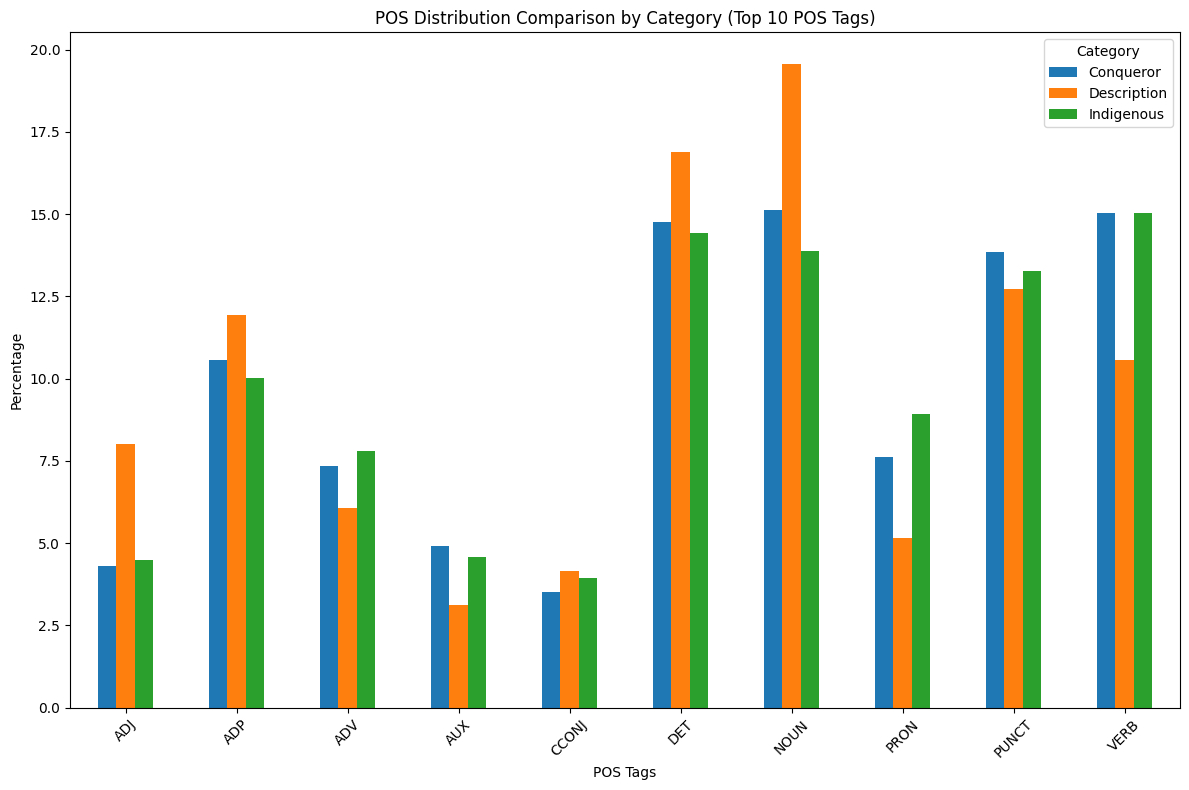


Visualization saved to: results/pos_distribution_comparison.png

=== WORKFLOW COMPLETE ===

Files generated:
1. results/segments_with_pos_features.csv - Enhanced dataset with POS features
2. results/pos_analysis_by_category.csv - Category-level summary statistics
3. results/pos_distribution_comparison.png - Comparative visualization

Next steps for your computational narratology analysis:
1. Statistical testing of POS differences between categories
2. Detailed analysis of function vs content word patterns
3. Correlation analysis between POS patterns and semantic categories
4. Integration with stylometric analysis results


In [ ]:

print("=== POS TAGGING WORKFLOW FOR COMPUTATIONAL NARRATOLOGY ===")
print("1. Setting up Stanza pipeline for Italian...")

try:
    # Try to load without downloading
    nlp = stanza.Pipeline(
        lang='it',
        processors='tokenize,pos,lemma',
        tokenize_no_ssplit=False,
        use_gpu=False,  # Safer default for Colab
        verbose=False
    )
except:
    # Download if not available
    print("Downloading Italian model (first time only)...")
    stanza.download('it')
    nlp = stanza.Pipeline(
        lang='it',
        processors='tokenize,pos,lemma',
        tokenize_no_ssplit=False,
        use_gpu=False,
        verbose=False
    )

print("Stanza pipeline initialized successfully!")

# Step 2: Load annotated segments
df_segments = pd.read_csv('results/processed_segments.csv')

# Filter to target categories (Indigenous, Description, Conqueror)
target_categories = ['Indigenous', 'Description', 'Conqueror']
df_segments = df_segments[df_segments['main_category'].isin(target_categories)].copy()

print(f"Working with {len(df_segments)} segments across {len(target_categories)} categories")
print(f"Categories: {df_segments['main_category'].value_counts()}")

# Step 3: Define POS tagging function
def extract_pos_features(text, nlp_pipeline):
    """
    Extract comprehensive POS features from text using Stanza
    Returns detailed linguistic information for computational narratology
    """
    if pd.isna(text) or not text.strip():
        return {
            'pos_tags': [],
            'lemmas': [],
            'pos_counts': {},
            'pos_distribution': {},
            'dominant_pos': None,
            'lexical_diversity': 0,
            'function_content_ratio': 0,
            'total_tokens': 0
        }

    try:
        # Process text with Stanza
        doc = nlp_pipeline(str(text))

        # Extract tokens, POS tags, and lemmas
        tokens = []
        pos_tags = []
        lemmas = []

        for sentence in doc.sentences:
            for word in sentence.words:
                tokens.append(word.text)
                pos_tags.append(word.upos)  # Universal POS tags
                lemmas.append(word.lemma)

        # Calculate POS statistics
        pos_counts = Counter(pos_tags)
        total_tokens = len(pos_tags)

        if total_tokens == 0:
            pos_distribution = {}
            dominant_pos = None
            lexical_diversity = 0
            function_content_ratio = 0
        else:
            # POS distribution percentages
            pos_distribution = {pos: count/total_tokens for pos, count in pos_counts.items()}

            # Dominant POS category
            dominant_pos = pos_counts.most_common(1)[0][0] if pos_counts else None

            # Lexical diversity (unique lemmas / total tokens)
            unique_lemmas = len(set(lemmas))
            lexical_diversity = unique_lemmas / total_tokens if total_tokens > 0 else 0

            # Function vs Content word ratio
            function_pos = {'ADP', 'AUX', 'CCONJ', 'DET', 'PART', 'PRON', 'SCONJ'}
            content_pos = {'ADJ', 'ADV', 'INTJ', 'NOUN', 'PROPN', 'VERB'}

            function_count = sum(pos_counts[pos] for pos in function_pos if pos in pos_counts)
            content_count = sum(pos_counts[pos] for pos in content_pos if pos in pos_counts)

            function_content_ratio = function_count / content_count if content_count > 0 else float('inf')

        return {
            'tokens': tokens,
            'pos_tags': pos_tags,
            'lemmas': lemmas,
            'pos_counts': dict(pos_counts),
            'pos_distribution': pos_distribution,
            'dominant_pos': dominant_pos,
            'lexical_diversity': lexical_diversity,
            'function_content_ratio': function_content_ratio,
            'total_tokens': total_tokens
        }

    except Exception as e:
        print(f"Error processing text: {str(e)[:100]}...")
        return {
            'pos_tags': [],
            'lemmas': [],
            'pos_counts': {},
            'pos_distribution': {},
            'dominant_pos': None,
            'lexical_diversity': 0,
            'function_content_ratio': 0,
            'total_tokens': 0
        }

# Step 4: Apply POS tagging to all segments
print("\n2. Processing segments with POS tagging...")
print("This may take a few minutes depending on corpus size...")

# Process in batches to show progress
batch_size = 100
total_segments = len(df_segments)
pos_features = []

for i in range(0, total_segments, batch_size):
    batch_end = min(i + batch_size, total_segments)
    print(f"Processing batch {i//batch_size + 1}: segments {i+1}-{batch_end} of {total_segments}")

    batch_texts = df_segments.iloc[i:batch_end]['segment_text'].tolist()
    batch_features = [extract_pos_features(text, nlp) for text in batch_texts]
    pos_features.extend(batch_features)

# Add POS features to DataFrame
print("\n3. Adding POS features to DataFrame...")

# Extract individual feature columns
df_segments['pos_tags'] = [features['pos_tags'] for features in pos_features]
df_segments['lemmas'] = [features['lemmas'] for features in pos_features]
df_segments['pos_counts'] = [features['pos_counts'] for features in pos_features]
df_segments['pos_distribution'] = [features['pos_distribution'] for features in pos_features]
df_segments['dominant_pos'] = [features['dominant_pos'] for features in pos_features]
df_segments['lexical_diversity'] = [features['lexical_diversity'] for features in pos_features]
df_segments['function_content_ratio'] = [features['function_content_ratio'] for features in pos_features]
df_segments['total_tokens'] = [features['total_tokens'] for features in pos_features]

# Step 5: Category-level POS analysis
print("\n4. Analyzing POS distributions by category...")

def analyze_pos_by_category(df):
    """
    Comprehensive POS analysis by narrative category
    """
    category_pos_analysis = {}

    for category in df['main_category'].unique():
        category_data = df[df['main_category'] == category]

        # Aggregate all POS tags for this category
        all_pos_tags = []
        for pos_list in category_data['pos_tags']:
            all_pos_tags.extend(pos_list)

        # Calculate category-level statistics
        pos_counter = Counter(all_pos_tags)
        total_pos = len(all_pos_tags)

        if total_pos > 0:
            pos_distribution = {pos: count/total_pos for pos, count in pos_counter.items()}

            # Calculate average metrics
            avg_lexical_diversity = category_data['lexical_diversity'].mean()
            avg_function_content_ratio = category_data['function_content_ratio'].replace([np.inf, -np.inf], np.nan).mean()

            category_pos_analysis[category] = {
                'total_tokens': total_pos,
                'unique_pos_tags': len(pos_counter),
                'pos_distribution': pos_distribution,
                'pos_counts': dict(pos_counter),
                'top_5_pos': pos_counter.most_common(5),
                'avg_lexical_diversity': avg_lexical_diversity,
                'avg_function_content_ratio': avg_function_content_ratio,
                'segments_count': len(category_data)
            }

    return category_pos_analysis

category_analysis = analyze_pos_by_category(df_segments)

# Display results
for category, analysis in category_analysis.items():
    print(f"\n--- {category.upper()} ---")
    print(f"Segments: {analysis['segments_count']}")
    print(f"Total tokens: {analysis['total_tokens']:,}")
    print(f"Unique POS tags: {analysis['unique_pos_tags']}")
    print(f"Average lexical diversity: {analysis['avg_lexical_diversity']:.3f}")
    print(f"Average function/content ratio: {analysis['avg_function_content_ratio']:.3f}")
    print("Top 5 POS categories:")
    for pos, count in analysis['top_5_pos']:
        percentage = (count / analysis['total_tokens']) * 100
        print(f"  {pos}: {count:,} ({percentage:.1f}%)")

# Step 6: Save enhanced dataset
print("\n5. Saving enhanced dataset with POS features...")

# Save the enhanced DataFrame
output_path = 'results/segments_with_pos_features.csv'
df_segments.to_csv(output_path, index=False)
print(f"Enhanced dataset saved to: {output_path}")

# Save category-level analysis
analysis_summary = pd.DataFrame.from_dict(
    {cat: {
        'segments_count': data['segments_count'],
        'total_tokens': data['total_tokens'],
        'avg_lexical_diversity': data['avg_lexical_diversity'],
        'avg_function_content_ratio': data['avg_function_content_ratio'],
        'dominant_pos_1': data['top_5_pos'][0][0] if data['top_5_pos'] else None,
        'dominant_pos_1_pct': (data['top_5_pos'][0][1] / data['total_tokens'] * 100) if data['top_5_pos'] else 0,
        'dominant_pos_2': data['top_5_pos'][1][0] if len(data['top_5_pos']) > 1 else None,
        'dominant_pos_2_pct': (data['top_5_pos'][1][1] / data['total_tokens'] * 100) if len(data['top_5_pos']) > 1 else 0,
    } for cat, data in category_analysis.items()},
    orient='index'
)

analysis_summary.to_csv('results/pos_analysis_by_category.csv')
print("Category-level POS analysis saved to: results/pos_analysis_by_category.csv")

# Step 7: Create comparison visualizations
print("\n6. Creating POS distribution visualizations...")

# Prepare data for visualization
pos_comparison_data = []
for category, analysis in category_analysis.items():
    for pos, count in analysis['pos_counts'].items():
        percentage = (count / analysis['total_tokens']) * 100
        pos_comparison_data.append({
            'Category': category,
            'POS': pos,
            'Percentage': percentage,
            'Count': count
        })

pos_df = pd.DataFrame(pos_comparison_data)

# Create visualization (basic setup - can be enhanced)
plt.figure(figsize=(12, 8))
top_pos = pos_df.groupby('POS')['Count'].sum().nlargest(10).index
filtered_pos_df = pos_df[pos_df['POS'].isin(top_pos)]

pivot_data = filtered_pos_df.pivot(index='POS', columns='Category', values='Percentage')
pivot_data.plot(kind='bar', figsize=(12, 8))
plt.title('POS Distribution Comparison by Category (Top 10 POS Tags)')
plt.xlabel('POS Tags')
plt.ylabel('Percentage')
plt.legend(title='Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/pos_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: results/pos_distribution_comparison.png")

print("\n=== WORKFLOW COMPLETE ===")
print("\nFiles generated:")
print("1. results/segments_with_pos_features.csv - Enhanced dataset with POS features")
print("2. results/pos_analysis_by_category.csv - Category-level summary statistics")
print("3. results/pos_distribution_comparison.png - Comparative visualization")

print("\nNext steps for your computational narratology analysis:")
print("1. Statistical testing of POS differences between categories")
print("2. Detailed analysis of function vs content word patterns")
print("3. Correlation analysis between POS patterns and semantic categories")
print("4. Integration with stylometric analysis results")

Let's run significance test to evaluate robustness of results.

In [ ]:
print("=== STATISTICAL SIGNIFICANCE TESTING FOR POS DISTRIBUTIONS ===")

# Load the POS-enhanced dataset
df_segments = pd.read_csv('results/segments_with_pos_features.csv')

print(f"Loaded {len(df_segments)} segments")
print(f"Categories: {df_segments['main_category'].value_counts()}")

# Convert string representations back to actual lists (if needed)
import ast

def safe_eval(x):
    """Safely evaluate string representation of lists/dicts"""
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x if x is not None else []

# Ensure pos_tags and pos_counts are properly formatted
df_segments['pos_tags'] = df_segments['pos_tags'].apply(safe_eval)
df_segments['pos_counts'] = df_segments['pos_counts'].apply(safe_eval)

print("\n=== 1. CHI-SQUARE TESTS FOR POS CATEGORY ASSOCIATIONS ===")

def create_pos_contingency_table(df):
    """
    Create contingency table for chi-square test
    Rows: Categories, Columns: POS tags
    """
    categories = df['main_category'].unique()
    all_pos_tags = set()

    # Get all possible POS tags
    for _, row in df.iterrows():
        pos_counts = row['pos_counts'] if isinstance(row['pos_counts'], dict) else {}
        all_pos_tags.update(pos_counts.keys())

    all_pos_tags = sorted(list(all_pos_tags))

    # Create contingency table
    contingency_data = []
    category_labels = []

    for category in categories:
        category_data = df[df['main_category'] == category]
        category_pos_counts = Counter()

        # Aggregate all POS counts for this category
        for _, row in category_data.iterrows():
            pos_counts = row['pos_counts'] if isinstance(row['pos_counts'], dict) else {}
            for pos, count in pos_counts.items():
                category_pos_counts[pos] += count

        # Create row for contingency table
        row_counts = [category_pos_counts.get(pos, 0) for pos in all_pos_tags]
        contingency_data.append(row_counts)
        category_labels.append(category)

    contingency_table = np.array(contingency_data)

    return contingency_table, category_labels, all_pos_tags

# Create contingency table
contingency_table, categories, pos_tags = create_pos_contingency_table(df_segments)

print(f"Contingency table shape: {contingency_table.shape}")
print(f"Categories: {categories}")
print(f"POS tags analyzed: {len(pos_tags)}")

# Overall chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nOVERALL CHI-SQUARE TEST:")
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.2e}")
print(f"Significant at α=0.05: {'YES' if p_value < 0.05 else 'NO'}")

# Calculate effect size (Cramér's V)
n = contingency_table.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1)))
print(f"Cramér's V (effect size): {cramers_v:.3f}")

# Interpret effect size
if cramers_v >= 0.5:
    effect_interpretation = "Large effect"
elif cramers_v >= 0.3:
    effect_interpretation = "Medium effect"
elif cramers_v >= 0.1:
    effect_interpretation = "Small effect"
else:
    effect_interpretation = "Negligible effect"
print(f"Effect size interpretation: {effect_interpretation}")

print("\n=== 2. POST-HOC ANALYSIS: INDIVIDUAL POS TAG SIGNIFICANCE ===")

# Test each POS tag individually
pos_results = []

for i, pos_tag in enumerate(pos_tags):
    pos_counts_by_category = contingency_table[:, i]
    total_other_counts = contingency_table.sum(axis=1) - pos_counts_by_category

    # Skip if POS tag is too rare (less than 5 expected in any cell)
    if min(pos_counts_by_category) < 5:
        continue

    # Create 2x3 contingency table for this POS tag
    pos_contingency = np.array([pos_counts_by_category, total_other_counts]).T

    try:
        chi2_pos, p_pos, dof_pos, expected_pos = chi2_contingency(pos_contingency)

        # Calculate standardized residuals to identify which categories deviate most
        residuals = (pos_contingency - expected_pos) / np.sqrt(expected_pos)

        pos_results.append({
            'pos_tag': pos_tag,
            'chi2_statistic': chi2_pos,
            'p_value': p_pos,
            'significant': p_pos < 0.05,
            'categories': categories,
            'observed_counts': pos_counts_by_category.tolist(),
            'standardized_residuals': residuals[:, 0].tolist(),  # First column (POS counts)
            'total_occurrences': pos_counts_by_category.sum()
        })
    except Exception as e:
        continue

# Sort by significance
pos_results.sort(key=lambda x: x['p_value'])

print("SIGNIFICANT POS ASSOCIATIONS (p < 0.05):")
print("-" * 80)
print(f"{'POS Tag':<8} {'Chi2':<8} {'p-value':<12} {'Total':<8} {'Strongest Association'}")
print("-" * 80)

significant_results = [r for r in pos_results if r['significant']]

for result in significant_results[:15]:  # Top 15 most significant
    # Find category with highest standardized residual (strongest positive association)
    max_residual_idx = np.argmax(np.abs(result['standardized_residuals']))
    strongest_category = result['categories'][max_residual_idx]
    residual_value = result['standardized_residuals'][max_residual_idx]

    association_type = "+" if residual_value > 0 else "-"

    print(f"{result['pos_tag']:<8} {result['chi2_statistic']:<8.2f} {result['p_value']:<12.2e} {result['total_occurrences']:<8} {strongest_category} ({association_type}{abs(residual_value):.2f})")

print(f"\nTotal significant POS associations: {len(significant_results)} out of {len(pos_results)} tested")

print("\n=== 3. BONFERRONI CORRECTION FOR MULTIPLE TESTING ===")

# Apply Bonferroni correction
alpha_original = 0.05
alpha_bonferroni = alpha_original / len(pos_results)
bonferroni_significant = [r for r in pos_results if r['p_value'] < alpha_bonferroni]

print(f"Original α: {alpha_original}")
print(f"Bonferroni corrected α: {alpha_bonferroni:.6f}")
print(f"Significant after Bonferroni correction: {len(bonferroni_significant)}")

if bonferroni_significant:
    print("\nPOS TAGS SIGNIFICANT AFTER BONFERRONI CORRECTION:")
    for result in bonferroni_significant:
        max_residual_idx = np.argmax(np.abs(result['standardized_residuals']))
        strongest_category = result['categories'][max_residual_idx]
        residual_value = result['standardized_residuals'][max_residual_idx]
        association_type = "+" if residual_value > 0 else "-"

        print(f"  {result['pos_tag']}: p = {result['p_value']:.2e}, strongest: {strongest_category} ({association_type}{abs(residual_value):.2f})")

print("\n=== 4. PAIRWISE CATEGORY COMPARISONS ===")

# Compare each pair of categories
category_pairs = list(combinations(categories, 2))

print("PAIRWISE CATEGORY COMPARISONS:")
print("-" * 60)

pairwise_results = []

for cat1, cat2 in category_pairs:
    print(f"\n{cat1} vs {cat2}:")

    # Get data for these two categories
    cat1_data = df_segments[df_segments['main_category'] == cat1]
    cat2_data = df_segments[df_segments['main_category'] == cat2]

    # Aggregate POS counts
    cat1_pos_counts = Counter()
    cat2_pos_counts = Counter()

    for _, row in cat1_data.iterrows():
        pos_counts = row['pos_counts'] if isinstance(row['pos_counts'], dict) else {}
        for pos, count in pos_counts.items():
            cat1_pos_counts[pos] += count

    for _, row in cat2_data.iterrows():
        pos_counts = row['pos_counts'] if isinstance(row['pos_counts'], dict) else {}
        for pos, count in pos_counts.items():
            cat2_pos_counts[pos] += count

    # Create contingency table for this pair
    common_pos = set(cat1_pos_counts.keys()) | set(cat2_pos_counts.keys())
    common_pos = [pos for pos in common_pos if cat1_pos_counts[pos] + cat2_pos_counts[pos] >= 10]  # Minimum frequency

    if len(common_pos) > 0:
        pairwise_contingency = []
        for pos in common_pos:
            pairwise_contingency.append([cat1_pos_counts[pos], cat2_pos_counts[pos]])

        pairwise_contingency = np.array(pairwise_contingency).T

        try:
            chi2_pair, p_pair, dof_pair, expected_pair = chi2_contingency(pairwise_contingency)

            print(f"  Chi-square: {chi2_pair:.2f}, p-value: {p_pair:.2e}")
            print(f"  Significant: {'YES' if p_pair < 0.05 else 'NO'}")

            pairwise_results.append({
                'comparison': f"{cat1} vs {cat2}",
                'chi2': chi2_pair,
                'p_value': p_pair,
                'significant': p_pair < 0.05
            })

        except Exception as e:
            print(f"  Error in comparison: {e}")

print("\n=== 5. CONTINUOUS MEASURES ANALYSIS ===")

# Test differences in continuous POS-derived measures
continuous_measures = ['lexical_diversity', 'function_content_ratio']

print("ANALYSIS OF CONTINUOUS POS MEASURES:")
print("-" * 50)

for measure in continuous_measures:
    print(f"\n{measure.upper()}:")

    # Remove infinite values for function_content_ratio
    if measure == 'function_content_ratio':
        df_clean = df_segments[df_segments[measure] != np.inf].copy()
        df_clean = df_clean[df_clean[measure] != -np.inf]
    else:
        df_clean = df_segments.copy()

    # Group by category
    groups = [df_clean[df_clean['main_category'] == cat][measure].dropna() for cat in categories]

    # Descriptive statistics
    for i, cat in enumerate(categories):
        values = groups[i]
        print(f"  {cat}: mean={values.mean():.3f}, std={values.std():.3f}, n={len(values)}")

    # Kruskal-Wallis test (non-parametric ANOVA)
    try:
        h_stat, p_kruskal = kruskal(*groups)
        print(f"  Kruskal-Wallis H: {h_stat:.3f}, p-value: {p_kruskal:.2e}")
        print(f"  Significant difference: {'YES' if p_kruskal < 0.05 else 'NO'}")
    except Exception as e:
        print(f"  Error in Kruskal-Wallis test: {e}")

print("\n=== 6. SUMMARY AND RECOMMENDATIONS ===")

# Summary of findings
total_tests = len(pos_results)
significant_uncorrected = len(significant_results)
significant_corrected = len(bonferroni_significant)

print("STATISTICAL SUMMARY:")
print(f"- Overall POS distribution difference: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (p = {p_value:.2e})")
print(f"- Effect size (Cramér's V): {cramers_v:.3f} ({effect_interpretation})")
print(f"- Individual POS tests: {significant_uncorrected}/{total_tests} significant before correction")
print(f"- Individual POS tests: {significant_corrected}/{total_tests} significant after Bonferroni correction")

print(f"\nRECOMMENDations FOR YOUR PAPER:")
if significant_corrected > 0:
    print("✓ Strong evidence for POS differences between narrative categories")
    print("✓ Use Bonferroni-corrected results for conservative claims")
    print("✓ Report effect sizes alongside p-values")
else:
    print("⚠ Limited evidence for POS differences after multiple testing correction")
    print("⚠ Consider narrative categories may not be grammatically distinct")
    print("⚠ Focus on descriptive analysis rather than significance testing")

# Save detailed results
results_summary = pd.DataFrame(pos_results)
results_summary.to_csv('results/pos_significance_tests.csv', index=False)

pairwise_summary = pd.DataFrame(pairwise_results)
pairwise_summary.to_csv('results/pairwise_category_tests.csv', index=False)

print(f"\nDetailed results saved to:")
print(f"- results/pos_significance_tests.csv")
print(f"- results/pairwise_category_tests.csv")

print("\n=== ANALYSIS COMPLETE ===")


=== STATISTICAL SIGNIFICANCE TESTING FOR POS DISTRIBUTIONS ===
Loaded 824 segments
Categories: main_category
Indigenous     367
Description    233
Conqueror      224
Name: count, dtype: int64

=== 1. CHI-SQUARE TESTS FOR POS CATEGORY ASSOCIATIONS ===
Contingency table shape: (3, 14)
Categories: ['Description', 'Conqueror', 'Indigenous']
POS tags analyzed: 14

OVERALL CHI-SQUARE TEST:
Chi-square statistic: 478.43
Degrees of freedom: 26
P-value: 9.97e-85
Significant at α=0.05: YES
Cramér's V (effect size): 0.108
Effect size interpretation: Small effect

=== 2. POST-HOC ANALYSIS: INDIVIDUAL POS TAG SIGNIFICANCE ===
SIGNIFICANT POS ASSOCIATIONS (p < 0.05):
--------------------------------------------------------------------------------
POS Tag  Chi2     p-value      Total    Strongest Association
--------------------------------------------------------------------------------
ADJ      108.46   2.81e-24     1125     Description (+8.43)
NOUN     91.58    1.30e-20     3248     Description (+7

# Qualitative analysis of POS

Now let's performe a qualitative analysis of main lemmas in each POS category (limited to NOUN, ADJ, VERB) to explore semantic differences between various focalizations. Only "Indigenous" and "Conqueror" are taken into consideration, as "Narrator" offer too little example for a robust analysis. Description subcategories 'Soldiers' and 'Indigenous' are merged into the relative main categories, as the interest is in exploring semantic rather then discursive or narrative elements. The script performe also a comparison of the top 100 words for each POS and category, measuring the item's distinctiveness from the other category. Each word is categorized as VERY HIGH, HIGH, MODERATE, LOW distinctive according to the following thresholds: if ratio >= 5.0: → VERY HIGH
elif ratio >= 3.0: → HIGH, elif ratio >= 2.0: → MODERATE, else: → LOW.


In [ ]:
print("=== FREQUENCY EXTRACTION FOR MANUAL QUALITATIVE ANALYSIS ===")
print("Extracting ADJ, VERB, NOUN frequencies for Conqueror vs Indigenous")
print("Including thematic subcategories for comprehensive analysis")

# Load POS-enhanced dataset
df_segments = pd.read_csv('results/segments_with_pos_features.csv')

# Filter to target categories including thematic subcategories
print("Including thematic subcategories:")
print("- Indigenous: main_category='Indigenous' OR (main_category='Description' AND subcategory='Indigenous')")
print("- Conqueror: main_category='Conqueror' OR (main_category='Description' AND subcategory='Soldier')")

# Create enhanced category filters
indigenous_filter = (
    (df_segments['main_category'] == 'Indigenous') |
    ((df_segments['main_category'] == 'Description') & (df_segments['subcategory'] == 'Indigenous'))
)

conqueror_filter = (
    (df_segments['main_category'] == 'Conqueror') |
    ((df_segments['main_category'] == 'Description') & (df_segments['subcategory'] == 'Soldier'))
)

# Apply filters
df_indigenous = df_segments[indigenous_filter].copy()
df_conqueror = df_segments[conqueror_filter].copy()

# Combine into single dataframe with unified categories
df_indigenous['unified_category'] = 'Indigenous'
df_conqueror['unified_category'] = 'Conqueror'
df_filtered = pd.concat([df_indigenous, df_conqueror], ignore_index=True)

print(f"\nAnalyzing {len(df_filtered)} segments with thematic subcategories:")
print(f"Indigenous (including Description→Indigenous): {len(df_indigenous)} segments")
print(f"Conqueror (including Description→Soldier): {len(df_conqueror)} segments")

# Show breakdown by original categories
print(f"\nBreakdown by original annotation:")
breakdown = df_filtered.groupby(['unified_category', 'main_category', 'subcategory']).size().reset_index(name='count')
for _, row in breakdown.iterrows():
    subcat_str = f" → {row['subcategory']}" if pd.notna(row['subcategory']) and row['subcategory'] != '' else ""
    print(f"  {row['unified_category']}: {row['main_category']}{subcat_str} = {row['count']} segments")

# Convert string representations to lists
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x if x is not None else []

df_filtered['pos_tags'] = df_filtered['pos_tags'].apply(safe_eval)
df_filtered['lemmas'] = df_filtered['lemmas'].apply(safe_eval)

print("\n=== EXTRACTING WORD FREQUENCIES BY POS ===")

def extract_word_frequencies(df, unified_category, pos_tag):
    """
    Extract word frequencies for a specific unified category and POS tag
    """
    category_data = df[df['unified_category'] == unified_category]
    word_list = []

    for _, row in category_data.iterrows():
        pos_tags = row['pos_tags']
        lemmas = row['lemmas']

        if not pos_tags or not lemmas:
            continue

        # Extract words with the target POS tag
        for pos, lemma in zip(pos_tags, lemmas):
            if pos == pos_tag:
                # Clean the lemma (lowercase, basic cleaning)
                clean_word = lemma.lower().strip()

                # Basic filtering (keep words with letters, minimum length 2)
                if clean_word.isalpha() and len(clean_word) >= 2:
                    word_list.append(clean_word)

    # Count frequencies
    word_counter = Counter(word_list)

    return word_counter

# Target POS tags
target_pos = ['ADJ', 'VERB', 'NOUN']
target_categories = ['Conqueror', 'Indigenous']  # Now using unified categories

# Extract frequencies for each unified category and POS
print("Extracting frequencies...")

all_frequencies = {}
for category in target_categories:
    all_frequencies[category] = {}
    for pos in target_pos:
        frequencies = extract_word_frequencies(df_filtered, category, pos)
        all_frequencies[category][pos] = frequencies

        print(f"{category} {pos}: {sum(frequencies.values())} total words, {len(frequencies)} unique words")

print("\n=== CREATING FREQUENCY LISTS WITH DISTINCTIVENESS ANALYSIS ===")

def calculate_distinctiveness(freq1, freq2, word, smoothing=1):
    """
    Calculate distinctiveness score for a word between two frequency distributions
    Returns ratio indicating how distinctive the word is to freq1 vs freq2
    """
    count1 = freq1.get(word, 0)
    count2 = freq2.get(word, 0)

    # Add smoothing to avoid division by zero
    ratio = (count1 + smoothing) / (count2 + smoothing)

    # Calculate total frequency for filtering
    total_freq = count1 + count2

    return ratio, total_freq

# Create comprehensive frequency lists with distinctiveness
for pos in target_pos:
    print(f"\n--- {pos} FREQUENCY LISTS WITH DISTINCTIVENESS ---")

    # Get frequencies for both categories
    conqueror_freq = all_frequencies['Conqueror'][pos]
    indigenous_freq = all_frequencies['Indigenous'][pos]

    # Create comprehensive word list from both categories
    all_words = set(conqueror_freq.keys()) | set(indigenous_freq.keys())

    # Calculate distinctiveness for all words
    conqueror_distinctive = []
    indigenous_distinctive = []

    for word in all_words:
        conq_count = conqueror_freq.get(word, 0)
        indig_count = indigenous_freq.get(word, 0)
        total_count = conq_count + indig_count

        # Only analyze words with minimum frequency (reduce noise)
        if total_count >= 2:
            # Calculate distinctiveness ratios
            conq_ratio, _ = calculate_distinctiveness(conqueror_freq, indigenous_freq, word)
            indig_ratio, _ = calculate_distinctiveness(indigenous_freq, conqueror_freq, word)

            conqueror_distinctive.append({
                'word': word,
                'frequency': conq_count,
                'other_category_freq': indig_count,
                'total_freq': total_count,
                'distinctiveness_ratio': conq_ratio,
                'distinctiveness_score': conq_ratio * conq_count  # Weight by frequency
            })

            indigenous_distinctive.append({
                'word': word,
                'frequency': indig_count,
                'other_category_freq': conq_count,
                'total_freq': total_count,
                'distinctiveness_ratio': indig_ratio,
                'distinctiveness_score': indig_ratio * indig_count  # Weight by frequency
            })

    # Sort by distinctiveness score (high ratio + high frequency)
    conqueror_distinctive.sort(key=lambda x: x['distinctiveness_score'], reverse=True)
    indigenous_distinctive.sort(key=lambda x: x['distinctiveness_score'], reverse=True)

    print(f"Conqueror {pos}: analyzing {len(conqueror_distinctive)} words")
    print(f"Indigenous {pos}: analyzing {len(indigenous_distinctive)} words")

    # Take top words for each category
    conqueror_top_100 = conqueror_distinctive[:100]
    indigenous_top_100 = indigenous_distinctive[:100]

    # Create enhanced dataframes with distinctiveness markers
    def create_enhanced_df(word_list, category_name):
        df = pd.DataFrame(word_list)
        df['category'] = category_name
        df['rank'] = range(1, len(df) + 1)

        # Add distinctiveness markers (text-based, no icons)
        df['distinctiveness_level'] = df['distinctiveness_ratio'].apply(
            lambda x: 'VERY_HIGH' if x >= 5.0 else 'HIGH' if x >= 3.0 else 'MODERATE' if x >= 2.0 else 'LOW'
        )

        # Add exclusivity marker (text-based)
        df['exclusive'] = df['other_category_freq'].apply(lambda x: 'EXCLUSIVE' if x == 0 else '')

        # Add combined priority score for sorting
        df['priority'] = df.apply(lambda row:
            100 if row['exclusive'] == 'EXCLUSIVE' and row['distinctiveness_level'] == 'VERY_HIGH' else
            90 if row['exclusive'] == 'EXCLUSIVE' and row['distinctiveness_level'] == 'HIGH' else
            80 if row['exclusive'] == 'EXCLUSIVE' else
            70 if row['distinctiveness_level'] == 'VERY_HIGH' else
            60 if row['distinctiveness_level'] == 'HIGH' else
            50 if row['distinctiveness_level'] == 'MODERATE' else 10, axis=1)

        # Reorder columns for better readability
        cols = ['rank', 'word', 'frequency', 'other_category_freq', 'distinctiveness_ratio',
                'distinctiveness_level', 'exclusive', 'priority', 'distinctiveness_score']
        return df[cols]

    # Create enhanced dataframes
    conqueror_df = create_enhanced_df(conqueror_top_100, 'Conqueror')
    indigenous_df = create_enhanced_df(indigenous_top_100, 'Indigenous')

    # Save enhanced files (both CSV and Excel)
    conqueror_df.to_csv(f'results/conqueror_{pos.lower()}_frequencies_enhanced.csv', index=False)
    indigenous_df.to_csv(f'results/indigenous_{pos.lower()}_frequencies_enhanced.csv', index=False)

    # Save Excel files with better formatting
    with pd.ExcelWriter(f'results/conqueror_{pos.lower()}_frequencies_enhanced.xlsx', engine='openpyxl') as writer:
        conqueror_df.to_excel(writer, sheet_name='Conqueror_Words', index=False)

    with pd.ExcelWriter(f'results/indigenous_{pos.lower()}_frequencies_enhanced.xlsx', engine='openpyxl') as writer:
        indigenous_df.to_excel(writer, sheet_name='Indigenous_Words', index=False)

    # Create side-by-side comparison with distinctiveness
    comparison_data = []
    max_length = max(len(conqueror_top_100), len(indigenous_top_100))

    for i in range(max_length):
        row = {}

        # Conqueror data
        if i < len(conqueror_top_100):
            c_data = conqueror_top_100[i]
            row['conqueror_rank'] = i + 1
            row['conqueror_word'] = c_data['word']
            row['conqueror_freq'] = c_data['frequency']
            row['conqueror_distinctiveness'] = f"{c_data['distinctiveness_ratio']:.1f}"
            row['conqueror_level'] = (
                'VERY_HIGH' if c_data['distinctiveness_ratio'] >= 5.0 else
                'HIGH' if c_data['distinctiveness_ratio'] >= 3.0 else
                'MODERATE' if c_data['distinctiveness_ratio'] >= 2.0 else 'LOW'
            )
            row['conqueror_exclusive'] = 'EXCLUSIVE' if c_data['other_category_freq'] == 0 else ''
        else:
            row.update({
                'conqueror_rank': '', 'conqueror_word': '', 'conqueror_freq': '',
                'conqueror_distinctiveness': '', 'conqueror_level': '', 'conqueror_exclusive': ''
            })

        # Indigenous data
        if i < len(indigenous_top_100):
            i_data = indigenous_top_100[i]
            row['indigenous_rank'] = i + 1
            row['indigenous_word'] = i_data['word']
            row['indigenous_freq'] = i_data['frequency']
            row['indigenous_distinctiveness'] = f"{i_data['distinctiveness_ratio']:.1f}"
            row['indigenous_level'] = (
                'VERY_HIGH' if i_data['distinctiveness_ratio'] >= 5.0 else
                'HIGH' if i_data['distinctiveness_ratio'] >= 3.0 else
                'MODERATE' if i_data['distinctiveness_ratio'] >= 2.0 else 'LOW'
            )
            row['indigenous_exclusive'] = 'EXCLUSIVE' if i_data['other_category_freq'] == 0 else ''
        else:
            row.update({
                'indigenous_rank': '', 'indigenous_word': '', 'indigenous_freq': '',
                'indigenous_distinctiveness': '', 'indigenous_level': '', 'indigenous_exclusive': ''
            })

        comparison_data.append(row)

    # Save enhanced comparison file (CSV and Excel)
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df.to_csv(f'results/{pos.lower()}_comparison_enhanced.csv', index=False)

    with pd.ExcelWriter(f'results/{pos.lower()}_comparison_enhanced.xlsx', engine='openpyxl') as writer:
        comparison_df.to_excel(writer, sheet_name='Side_by_Side_Comparison', index=False)

    print(f"Saved CSV: results/conqueror_{pos.lower()}_frequencies_enhanced.csv")
    print(f"Saved CSV: results/indigenous_{pos.lower()}_frequencies_enhanced.csv")
    print(f"Saved CSV: results/{pos.lower()}_comparison_enhanced.csv")
    print(f"Saved Excel: results/conqueror_{pos.lower()}_frequencies_enhanced.xlsx")
    print(f"Saved Excel: results/indigenous_{pos.lower()}_frequencies_enhanced.xlsx")
    print(f"Saved Excel: results/{pos.lower()}_comparison_enhanced.xlsx")

print("\n=== ENHANCED PREVIEW WITH DISTINCTIVENESS MARKERS ===")

# Show preview with distinctiveness analysis
for pos in target_pos:
    print(f"\n--- TOP 15 MOST DISTINCTIVE {pos} WORDS ---")

    conqueror_freq = all_frequencies['Conqueror'][pos]
    indigenous_freq = all_frequencies['Indigenous'][pos]

    # Calculate distinctiveness for preview
    all_words = set(conqueror_freq.keys()) | set(indigenous_freq.keys())
    distinctive_preview = []

    for word in all_words:
        conq_count = conqueror_freq.get(word, 0)
        indig_count = indigenous_freq.get(word, 0)
        total_count = conq_count + indig_count

        if total_count >= 2:
            if conq_count > indig_count:
                ratio = (conq_count + 1) / (indig_count + 1)
                category = 'Conqueror'
                main_freq = conq_count
                other_freq = indig_count
            else:
                ratio = (indig_count + 1) / (conq_count + 1)
                category = 'Indigenous'
                main_freq = indig_count
                other_freq = conq_count

            distinctive_preview.append({
                'word': word,
                'category': category,
                'frequency': main_freq,
                'other_freq': other_freq,
                'ratio': ratio,
                'score': ratio * main_freq
            })

    # Sort by distinctiveness score and show top 15
    distinctive_preview.sort(key=lambda x: x['score'], reverse=True)

    for item in distinctive_preview[:15]:
        markers = ('VERY_HIGH' if item['ratio'] >= 5.0 else
                  'HIGH' if item['ratio'] >= 3.0 else
                  'MODERATE' if item['ratio'] >= 2.0 else 'LOW')
        exclusive = 'EXCLUSIVE' if item['other_freq'] == 0 else ''

        print(f"  {item['word']:<15} ({item['category']:<10}) "
              f"freq: {item['frequency']:<3} ratio: {item['ratio']:<5.1f} {markers} {exclusive}")

print("\n=== ENHANCED FILES GENERATED ===")
print("\nCSV files (for programming/processing):")
for category in ['conqueror', 'indigenous']:
    for pos in target_pos:
        print(f"- results/{category}_{pos.lower()}_frequencies_enhanced.csv")

print("\nExcel files (for manual analysis):")
for category in ['conqueror', 'indigenous']:
    for pos in target_pos:
        print(f"- results/{category}_{pos.lower()}_frequencies_enhanced.xlsx")

print("\nComparison files (side-by-side):")
for pos in target_pos:
    print(f"- results/{pos.lower()}_comparison_enhanced.csv")
    print(f"- results/{pos.lower()}_comparison_enhanced.xlsx")

print("\n=== EXCEL ANALYSIS WORKFLOW ===")
print("1. Open Excel files (.xlsx) for best experience")
print("2. Use Data -> Filter to enable column filtering")
print("3. Sort by 'priority' column (highest first)")
print("4. Filter by 'distinctiveness_level' (EXCLUSIVE, VERY_HIGH)")
print("5. Filter by 'exclusive' column to see category-unique words")
print("6. Use conditional formatting to highlight high values")

print("\n=== LEGEND FOR DISTINCTIVENESS LEVELS ===")
print("VERY_HIGH = Very distinctive (ratio ≥ 5.0) - appears 5x+ more in this category")
print("HIGH      = Highly distinctive (ratio ≥ 3.0) - appears 3x+ more in this category")
print("MODERATE  = Distinctive (ratio ≥ 2.0) - appears 2x+ more in this category")
print("LOW       = Low distinctiveness (ratio < 2.0)")
print("EXCLUSIVE = Appears ONLY in this category")
print("\nColumns in enhanced files:")
print("- frequency: count in main category")
print("- other_category_freq: count in other category")
print("- distinctiveness_ratio: how many times more frequent in main category")
print("- distinctiveness_level: text-based level (VERY_HIGH, HIGH, MODERATE, LOW)")
print("- exclusive: EXCLUSIVE for words appearing only in one category")
print("- priority: numerical score for sorting (100=EXCLUSIVE+VERY_HIGH, 90=EXCLUSIVE+HIGH, etc.)")

print("\n=== ANALYSIS READY FOR MANUAL INSPECTION ===")



=== FREQUENCY EXTRACTION FOR MANUAL QUALITATIVE ANALYSIS ===
Extracting ADJ, VERB, NOUN frequencies for Conqueror vs Indigenous
Including thematic subcategories for comprehensive analysis
Including thematic subcategories:
- Indigenous: main_category='Indigenous' OR (main_category='Description' AND subcategory='Indigenous')
- Conqueror: main_category='Conqueror' OR (main_category='Description' AND subcategory='Soldier')

Analyzing 684 segments with thematic subcategories:
Indigenous (including Description→Indigenous): 427 segments
Conqueror (including Description→Soldier): 257 segments

Breakdown by original annotation:
  Conqueror: Conqueror → UNLABELLED = 224 segments
  Conqueror: Description → Soldier = 33 segments
  Indigenous: Description → Indigenous = 60 segments
  Indigenous: Indigenous → UNLABELLED = 367 segments

=== EXTRACTING WORD FREQUENCIES BY POS ===
Extracting frequencies...
Conqueror ADJ: 276 total words, 182 unique words
Conqueror VERB: 870 total words, 401 unique word

# Syntactic role analysis

The final analysis examined syntactic role distribution to quantify agency representation across narrative categories.

=== SYNTACTIC ROLE ANALYSIS: AGENCY & NARRATIVE ROLES ===
Analyzing who acts vs. who is acted upon in colonial discourse

Total segments to analyze: 684
  Indigenous: 427
  Conqueror: 257

Initializing Stanza pipeline with dependency parsing...
Pipeline ready

Processing segments for syntactic role analysis...
This will take several minutes...

Processed 50/684 segments
Processed 100/684 segments
Processed 150/684 segments
Processed 200/684 segments
Processed 250/684 segments
Processed 300/684 segments
Processed 350/684 segments
Processed 400/684 segments
Processed 450/684 segments
Processed 500/684 segments
Processed 550/684 segments
Processed 600/684 segments
Processed 650/684 segments
Processed 684/684 segments

Analysis complete. Processing results...

SYNTACTIC ROLE ANALYSIS RESULTS

INDIGENOUS
----------------------------------------------------------------------
Segments analyzed: 427

AGENCY METRICS:
  Agent roles (subjects): 493
  Patient roles (objects/passive subjects): 639


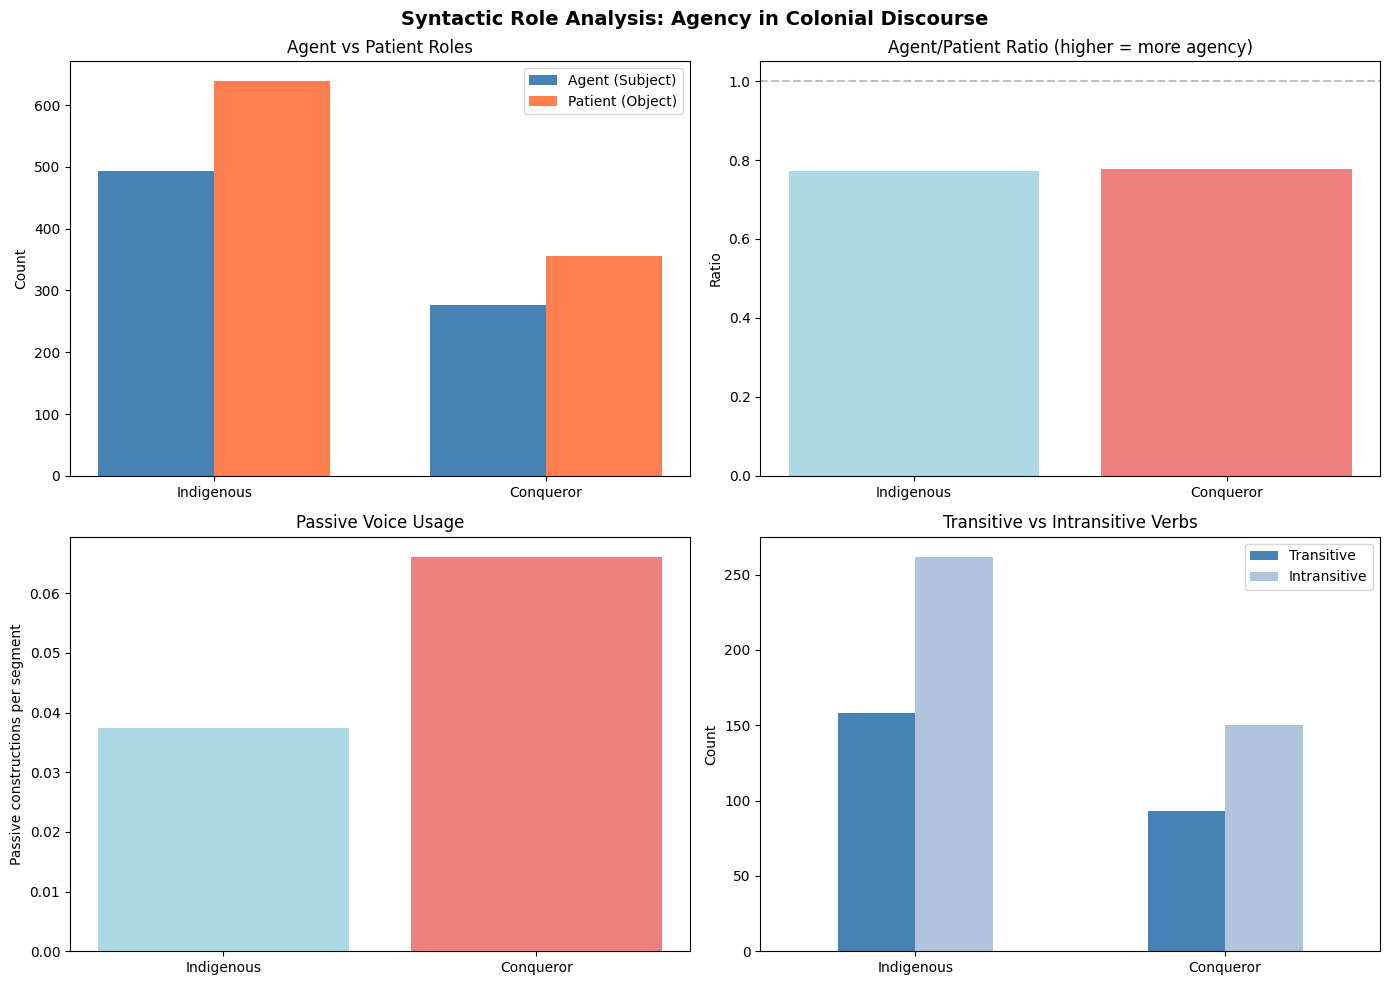

In [ ]:
print("=== SYNTACTIC ROLE ANALYSIS: AGENCY & NARRATIVE ROLES ===")
print("Analyzing who acts vs. who is acted upon in colonial discourse\n")

# Load data with POS features
df_segments = pd.read_csv('results/segments_with_pos_features.csv')

# Apply category filters
indigenous_filter = (
    (df_segments['main_category'] == 'Indigenous') |
    ((df_segments['main_category'] == 'Description') & (df_segments['subcategory'] == 'Indigenous'))
)

conqueror_filter = (
    (df_segments['main_category'] == 'Conqueror') |
    ((df_segments['main_category'] == 'Description') & (df_segments['subcategory'] == 'Soldier'))
)

df_indigenous = df_segments[indigenous_filter].copy()
df_conqueror = df_segments[conqueror_filter].copy()

df_indigenous['unified_category'] = 'Indigenous'
df_conqueror['unified_category'] = 'Conqueror'
df_frames = pd.concat([df_indigenous, df_conqueror], ignore_index=True)

print(f"Total segments to analyze: {len(df_frames)}")
print(f"  Indigenous: {len(df_indigenous)}")
print(f"  Conqueror: {len(df_conqueror)}\n")

# Initialize Stanza with dependency parsing
print("Initializing Stanza pipeline with dependency parsing...")
try:
    nlp = stanza.Pipeline(
        'it',
        processors='tokenize,pos,lemma,depparse',
        use_gpu=False,
        verbose=False
    )
    print("Pipeline ready\n")
except:
    print("Downloading Italian models...")
    stanza.download('it')
    nlp = stanza.Pipeline(
        'it',
        processors='tokenize,pos,lemma,depparse',
        use_gpu=False,
        verbose=False
    )
    print("Pipeline ready\n")

def analyze_semantic_roles(text, nlp_pipeline):
    """
    Extract syntactic roles and agency patterns from text

    Returns dictionary with:
    - agent_count: number of times category acts as subject
    - patient_count: number of times category acts as object
    - active_verbs: list of verbs where category is agent
    - passive_constructions: count of passive voice
    - transitive_actions: verbs with direct objects
    - intransitive_verbs: verbs without objects
    """
    if pd.isna(text) or not text.strip():
        return None

    try:
        doc = nlp_pipeline(text)

        results = {
            'subjects': [],           # nsubj - nominal subjects (AGENTS)
            'objects': [],            # obj - direct objects (PATIENTS)
            'passive_subjects': [],   # nsubj:pass - subjects in passive
            'oblique_agents': [],     # obl:agent - agents in passive by-phrase
            'active_verbs': [],       # verbs with active subjects
            'passive_verbs': [],      # verbs in passive voice
            'transitive_verbs': [],   # verbs with direct objects
            'intransitive_verbs': [], # verbs without objects
            'agent_count': 0,
            'patient_count': 0,
            'passive_count': 0
        }

        for sent in doc.sentences:
            # Build verb index
            verb_dict = {}
            for word in sent.words:
                if word.upos == 'VERB':
                    verb_dict[word.id] = {
                        'lemma': word.lemma,
                        'text': word.text,
                        'has_subject': False,
                        'has_object': False,
                        'is_passive': False
                    }

            # Analyze dependencies
            for word in sent.words:
                # Active subject (AGENT role)
                if word.deprel == 'nsubj':
                    results['subjects'].append(word.lemma)
                    results['agent_count'] += 1

                    # Mark verb as having active subject
                    if word.head in verb_dict:
                        verb_dict[word.head]['has_subject'] = True
                        verb_lemma = verb_dict[word.head]['lemma']
                        results['active_verbs'].append(verb_lemma)

                # Passive subject (PATIENT role in passive construction)
                elif word.deprel == 'nsubj:pass':
                    results['passive_subjects'].append(word.lemma)
                    results['patient_count'] += 1
                    results['passive_count'] += 1

                    # Mark verb as passive
                    if word.head in verb_dict:
                        verb_dict[word.head]['is_passive'] = True
                        verb_lemma = verb_dict[word.head]['lemma']
                        results['passive_verbs'].append(verb_lemma)

                # Direct object (PATIENT role)
                elif word.deprel == 'obj':
                    results['objects'].append(word.lemma)
                    results['patient_count'] += 1

                    # Mark verb as transitive
                    if word.head in verb_dict:
                        verb_dict[word.head]['has_object'] = True

                # Agent in passive construction (by-phrase)
                elif word.deprel == 'obl:agent':
                    results['oblique_agents'].append(word.lemma)

            # Classify verbs
            for vid, vinfo in verb_dict.items():
                if vinfo['is_passive']:
                    continue  # Already counted

                if vinfo['has_subject']:
                    if vinfo['has_object']:
                        results['transitive_verbs'].append(vinfo['lemma'])
                    else:
                        results['intransitive_verbs'].append(vinfo['lemma'])

        return results

    except Exception as e:
        print(f"Error: {str(e)[:80]}")
        return None

# Process segments
print("Processing segments for syntactic role analysis...")
print("This will take several minutes...\n")

frame_results = []
batch_size = 50

for i in range(0, len(df_frames), batch_size):
    batch = df_frames.iloc[i:i+batch_size]

    for idx, row in batch.iterrows():
        result = analyze_semantic_roles(row['segment_text'], nlp)

        if result:
            frame_results.append({
                'segment_id': idx,
                'category': row['unified_category'],
                'text': row['segment_text'][:100],  # First 100 chars
                **result
            })

    processed = min(i + batch_size, len(df_frames))
    print(f"Processed {processed}/{len(df_frames)} segments")

print("\nAnalysis complete. Processing results...\n")

# Create results dataframe
df_results = pd.DataFrame(frame_results)

# Aggregate statistics by category
print("=" * 70)
print("SYNTACTIC ROLE ANALYSIS RESULTS")
print("=" * 70)

summary_stats = []

for category in ['Indigenous', 'Conqueror']:
    cat_data = df_results[df_results['category'] == category]

    total_segments = len(cat_data)
    total_agents = cat_data['agent_count'].sum()
    total_patients = cat_data['patient_count'].sum()
    total_passive = cat_data['passive_count'].sum()

    # Collect all verbs
    all_active_verbs = [v for verbs in cat_data['active_verbs'] for v in verbs]
    all_passive_verbs = [v for verbs in cat_data['passive_verbs'] for v in verbs]
    all_transitive = [v for verbs in cat_data['transitive_verbs'] for v in verbs]
    all_intransitive = [v for verbs in cat_data['intransitive_verbs'] for v in verbs]

    # Calculate ratios
    agent_patient_ratio = total_agents / max(total_patients, 1)
    passive_rate = total_passive / max(total_segments, 1)

    print(f"\n{category.upper()}")
    print("-" * 70)
    print(f"Segments analyzed: {total_segments}")
    print(f"\nAGENCY METRICS:")
    print(f"  Agent roles (subjects): {total_agents}")
    print(f"  Patient roles (objects/passive subjects): {total_patients}")
    print(f"  Agent/Patient ratio: {agent_patient_ratio:.2f}")
    print(f"  Passive constructions: {total_passive}")
    print(f"  Passive rate per segment: {passive_rate:.2f}")

    print(f"\nVERB PATTERNS:")
    print(f"  Active verbs (with subjects): {len(all_active_verbs)}")
    print(f"  Transitive verbs (with objects): {len(all_transitive)}")
    print(f"  Intransitive verbs: {len(all_intransitive)}")

    print(f"\nTOP 10 ACTIVE VERBS:")
    for verb, count in Counter(all_active_verbs).most_common(10):
        print(f"  {verb}: {count}")

    print(f"\nTOP 10 TRANSITIVE VERBS (acting on objects):")
    for verb, count in Counter(all_transitive).most_common(10):
        print(f"  {verb}: {count}")

    if all_passive_verbs:
        print(f"\nTOP PASSIVE CONSTRUCTIONS:")
        for verb, count in Counter(all_passive_verbs).most_common(5):
            print(f"  {verb}: {count}")

    # Store for comparison
    summary_stats.append({
        'category': category,
        'segments': total_segments,
        'agent_roles': total_agents,
        'patient_roles': total_patients,
        'agent_patient_ratio': agent_patient_ratio,
        'passive_constructions': total_passive,
        'passive_rate': passive_rate,
        'active_verbs': len(all_active_verbs),
        'transitive_verbs': len(all_transitive),
        'intransitive_verbs': len(all_intransitive)
    })

# Statistical comparison
print("\n" + "=" * 70)
print("COMPARATIVE ANALYSIS")
print("=" * 70)

indig_stats = summary_stats[0]
conq_stats = summary_stats[1]

print(f"\nAGENCY COMPARISON:")
print(f"  Agent/Patient ratio:")
print(f"    Indigenous: {indig_stats['agent_patient_ratio']:.2f}")
print(f"    Conqueror:  {conq_stats['agent_patient_ratio']:.2f}")
print(f"    Difference: {abs(indig_stats['agent_patient_ratio'] - conq_stats['agent_patient_ratio']):.2f}")

print(f"\n  Passive voice rate:")
print(f"    Indigenous: {indig_stats['passive_rate']:.2f} per segment")
print(f"    Conqueror:  {conq_stats['passive_rate']:.2f} per segment")

print(f"\n  Transitive actions (acting on objects):")
print(f"    Indigenous: {indig_stats['transitive_verbs']}")
print(f"    Conqueror:  {conq_stats['transitive_verbs']}")

# Statistical test
from scipy.stats import mannwhitneyu

indig_agent_patient = df_results[df_results['category'] == 'Indigenous']['agent_count'] / \
                      (df_results[df_results['category'] == 'Indigenous']['patient_count'] + 1)
conq_agent_patient = df_results[df_results['category'] == 'Conqueror']['agent_count'] / \
                     (df_results[df_results['category'] == 'Conqueror']['patient_count'] + 1)

stat, p_value = mannwhitneyu(indig_agent_patient, conq_agent_patient)

print(f"\n  Mann-Whitney U test for agent/patient ratio:")
print(f"    U-statistic: {stat:.2f}")
print(f"    P-value: {p_value:.4f}")
print(f"    Significant: {'YES' if p_value < 0.05 else 'NO'} (α=0.05)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Syntactic Role Analysis: Agency in Colonial Discourse', fontsize=14, fontweight='bold')

# 1. Agent vs Patient roles
categories = ['Indigenous', 'Conqueror']
agent_counts = [indig_stats['agent_roles'], conq_stats['agent_roles']]
patient_counts = [indig_stats['patient_roles'], conq_stats['patient_roles']]

x = np.arange(len(categories))
width = 0.35

axes[0,0].bar(x - width/2, agent_counts, width, label='Agent (Subject)', color='steelblue')
axes[0,0].bar(x + width/2, patient_counts, width, label='Patient (Object)', color='coral')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Agent vs Patient Roles')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(categories)
axes[0,0].legend()

# 2. Agent/Patient ratio
ratios = [indig_stats['agent_patient_ratio'], conq_stats['agent_patient_ratio']]
axes[0,1].bar(categories, ratios, color=['lightblue', 'lightcoral'])
axes[0,1].set_ylabel('Ratio')
axes[0,1].set_title('Agent/Patient Ratio (higher = more agency)')
axes[0,1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

# 3. Passive voice rate
passive_rates = [indig_stats['passive_rate'], conq_stats['passive_rate']]
axes[1,0].bar(categories, passive_rates, color=['lightblue', 'lightcoral'])
axes[1,0].set_ylabel('Passive constructions per segment')
axes[1,0].set_title('Passive Voice Usage')

# 4. Verb types
verb_data = pd.DataFrame({
    'Transitive': [indig_stats['transitive_verbs'], conq_stats['transitive_verbs']],
    'Intransitive': [indig_stats['intransitive_verbs'], conq_stats['intransitive_verbs']]
}, index=categories)

verb_data.plot(kind='bar', ax=axes[1,1], color=['steelblue', 'lightsteelblue'])
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Transitive vs Intransitive Verbs')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend()

plt.tight_layout()
plt.savefig('results/syntactic_role_analysis.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved to: results/syntactic_role_analysis.png")

# Save detailed results
df_results.to_csv('results/syntactic_roles_detailed.csv', index=False)
summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('results/syntactic_roles_summary.csv', index=False)

print("\nDetailed results saved to:")
print("  - results/syntactic_roles_detailed.csv")
print("  - results/syntactic_roles_summary.csv")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)